In [1]:
import os
import numpy as np
import pandas as pd
import h5py
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Paths
DATA_DIR = "../data"
H5_PATH = os.path.join(DATA_DIR, "tcir_io.h5")
META_PATH = os.path.join(DATA_DIR, "tcir_io_metadata_compact.csv")

# Training configuration
BATCH_SIZE = 32
EPOCHS = 30

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("HDF5 exists:", os.path.exists(H5_PATH))
print("Metadata exists:", os.path.exists(META_PATH))

I0000 00:00:1788879327.265735    1420 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788879327.793517    1420 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788879330.561629    1420 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
HDF5 exists: True
Metadata exists: True


W0000 00:00:1788879337.302230    1420 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
df = pd.read_csv(META_PATH)

print("Total frames:", len(df))
print("Total cyclones:", df["ID"].nunique())

# --------------------------------------------------
# Cyclone-wise split
# --------------------------------------------------

cyclones = df["ID"].unique()

train_ids, temp_ids = train_test_split(
    cyclones,
    test_size=0.20,
    random_state=SEED
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=SEED
)

train_df = df[df["ID"].isin(train_ids)].reset_index(drop=True)
val_df = df[df["ID"].isin(val_ids)].reset_index(drop=True)
test_df = df[df["ID"].isin(test_ids)].reset_index(drop=True)

print("\nTrain cyclones:", len(train_ids))
print("Validation cyclones:", len(val_ids))
print("Test cyclones:", len(test_ids))

print("\nTrain frames:", len(train_df))
print("Validation frames:", len(val_df))
print("Test frames:", len(test_df))

# Verify no cyclone leakage
assert set(train_df["ID"]).isdisjoint(val_df["ID"])
assert set(train_df["ID"]).isdisjoint(test_df["ID"])
assert set(val_df["ID"]).isdisjoint(test_df["ID"])

print("\nNo cyclone leakage: OK")

Total frames: 3205
Total cyclones: 75

Train cyclones: 60
Validation cyclones: 7
Test cyclones: 8

Train frames: 2546
Validation frames: 313
Test frames: 346

No cyclone leakage: OK


In [3]:
train_indices = train_df["matrix_index"].to_numpy(dtype=np.int64)
val_indices = val_df["matrix_index"].to_numpy(dtype=np.int64)
test_indices = test_df["matrix_index"].to_numpy(dtype=np.int64)

y_train = train_df["Vmax"].to_numpy(dtype=np.float32)
y_val = val_df["Vmax"].to_numpy(dtype=np.float32)
y_test = test_df["Vmax"].to_numpy(dtype=np.float32)

print("Train X indices:", train_indices.shape)
print("Train targets:", y_train.shape)

print("\nVmax:")
print("Train:", y_train.min(), "to", y_train.max())
print("Val  :", y_val.min(), "to", y_val.max())
print("Test :", y_test.min(), "to", y_test.max())

Train X indices: (2546,)
Train targets: (2546,)

Vmax:
Train: 15.0 to 145.0
Val  : 15.0 to 90.0
Test : 15.0 to 135.0


In [4]:
def calculate_channel_stats(h5_path, indices, batch_size=32):

    channel_sum = np.zeros(4, dtype=np.float64)
    channel_sq_sum = np.zeros(4, dtype=np.float64)
    count = 0

    with h5py.File(h5_path, "r") as f:

        matrix = f["matrix"]

        for start in range(0, len(indices), batch_size):

            batch_indices = indices[start:start + batch_size]

            # h5py requires increasing indices
            order = np.argsort(batch_indices)
            sorted_indices = batch_indices[order]

            X_sorted = np.asarray(
                matrix[sorted_indices],
                dtype=np.float32
            )

            X = np.empty_like(X_sorted)
            X[order] = X_sorted

            X = np.nan_to_num(
                X,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            X = X.reshape(-1, 4)

            channel_sum += X.sum(axis=0)
            channel_sq_sum += (X ** 2).sum(axis=0)

            count += X.shape[0]

    mean = channel_sum / count

    variance = (
        channel_sq_sum / count
        - mean ** 2
    )

    std = np.sqrt(
        np.maximum(variance, 1e-8)
    )

    return (
        mean.astype(np.float32),
        std.astype(np.float32)
    )


channel_mean, channel_std = calculate_channel_stats(
    H5_PATH,
    train_indices
)

print("Channel mean:")
print(channel_mean)

print("\nChannel std:")
print(channel_std)

Channel mean:
[264.42245    235.07243      0.37205586   0.49645817]

Channel std:
[32.387424   12.352411    0.41326427  1.5534363 ]


In [5]:
class TCIRSequence(tf.keras.utils.Sequence):

    def __init__(
        self,
        h5_path,
        indices,
        targets,
        mean,
        std,
        batch_size=32,
        shuffle=True,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.h5_path = h5_path
        self.indices = np.asarray(indices)
        self.targets = np.asarray(targets)

        self.mean = mean.reshape(1, 1, 1, 4)
        self.std = std.reshape(1, 1, 1, 4)

        self.batch_size = batch_size
        self.shuffle = shuffle

        self.h5_file = None
        self.matrix = None

        self.on_epoch_end()

    def _open_file(self):

        if self.h5_file is None:
            self.h5_file = h5py.File(
                self.h5_path,
                "r"
            )

            self.matrix = self.h5_file["matrix"]

    def __len__(self):

        return int(
            np.ceil(
                len(self.indices) /
                self.batch_size
            )
        )

    def __getitem__(self, batch_idx):

        self._open_file()

        start = batch_idx * self.batch_size

        end = min(
            start + self.batch_size,
            len(self.indices)
        )

        batch_indices = self.indices[start:end]
        batch_targets = self.targets[start:end]

        # h5py fancy indexing requires sorted indices
        order = np.argsort(batch_indices)

        sorted_indices = batch_indices[order]

        X_sorted = np.asarray(
            self.matrix[sorted_indices],
            dtype=np.float32
        )

        # Restore original order
        X = np.empty_like(X_sorted)
        X[order] = X_sorted

        # Remove invalid values
        X = np.nan_to_num(
            X,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        # Channel-wise normalization
        X = (
            X - self.mean
        ) / self.std

        return X, batch_targets

    def on_epoch_end(self):

        if self.shuffle:

            permutation = np.random.permutation(
                len(self.indices)
            )

            self.indices = self.indices[permutation]
            self.targets = self.targets[permutation]

    def __del__(self):

        try:
            if self.h5_file is not None:
                self.h5_file.close()
        except Exception:
            pass

In [6]:
train_loader = TCIRSequence(
    H5_PATH,
    train_indices,
    y_train,
    channel_mean,
    channel_std,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = TCIRSequence(
    H5_PATH,
    val_indices,
    y_val,
    channel_mean,
    channel_std,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = TCIRSequence(
    H5_PATH,
    test_indices,
    y_test,
    channel_mean,
    channel_std,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 80
Validation batches: 10
Test batches: 11


In [7]:
X_batch, y_batch = train_loader[0]

print("X shape:", X_batch.shape)
print("X dtype:", X_batch.dtype)

print("y shape:", y_batch.shape)
print("y dtype:", y_batch.dtype)

print("\nNaNs:", np.isnan(X_batch).sum())
print("Infs:", np.isinf(X_batch).sum())

print("\nX mean:", X_batch.mean())
print("X std :", X_batch.std())

X shape: (32, 201, 201, 4)
X dtype: float32
y shape: (32,)
y dtype: float32

NaNs: 0
Infs: 0

X mean: -0.07751837
X std : 0.9690809


In [8]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(201, 201, 4)
    ),

    tf.keras.layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,
        3,
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        256,
        3,
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(1)
])

model.summary()

W0000 00:00:1788879354.845136    1420 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1788879355.343061    1420 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5262 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 201, 201, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 201, 201, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,649 (1.62 MB)

 Trainable params: 422,689 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=tf.keras.losses.Huber(
        delta=10.0
    ),

    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        ),
        tf.keras.metrics.RootMeanSquaredError(
            name="rmse"
        )
    ]
)

In [10]:
os.makedirs("../models", exist_ok=True)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../models/baseline_best.keras",
    monitor="val_mae",
    mode="min",
    save_best_only=True,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    mode="min",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_mae",
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [11]:
history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=10,
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/10


I0000 00:00:1788879357.816371    1420 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1788879361.095585    2164 service.cc:153] XLA service 0x74c8fc04cae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788879361.095659    2164 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1788879361.161709    2164 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788879361.663294    2164 cuda_dnn.cc:461] Loaded cuDNN version 92501
I0000 00:00:1788879361.744857    2164 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4206__.63


 2/80 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 319.5209 - mae: 36.9521 - rmse: 41.8320  

I0000 00:00:1788879374.412774    2164 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


KeyboardInterrupt: 

In [ ]:
test_results = model.evaluate(
    test_loader,
    verbose=1
)

print("\nTest results:")

for name, value in zip(
    model.metrics_names,
    test_results
):
    print(f"{name}: {value:.4f}")

10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 110.6436 - mae: 15.2730 - rmse: 22.8521

I0000 00:00:1788825313.591669   12332 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 8 bytes spill stores, 8 bytes spill loads



11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 359ms/step - loss: 126.7626 - mae: 16.9181 - rmse: 25.1971

Test results:
loss: 126.7626
compile_metrics: 16.9181


In [ ]:
import matplotlib.pyplot as plt

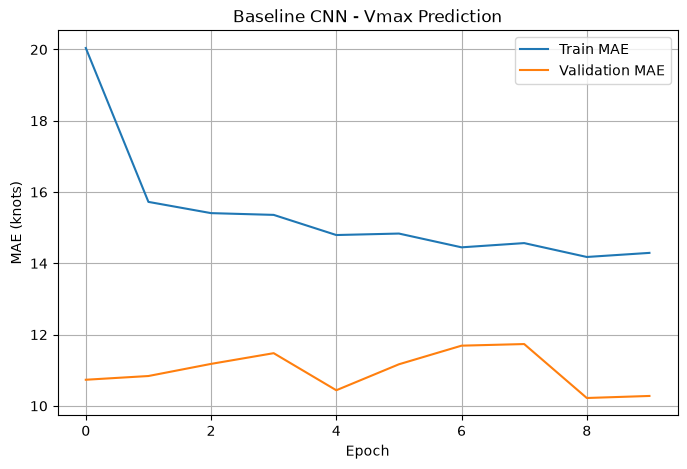

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["mae"],
    label="Train MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE (knots)")
plt.title("Baseline CNN - Vmax Prediction")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
predictions = model.predict(
    test_loader,
    verbose=1
).flatten()

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("Test MAE :", mae)
print("Test RMSE:", rmse)

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step
Test MAE : 16.918088912963867
Test RMSE: 25.19711354996838


In [ ]:
results = pd.DataFrame({
    "Actual_Vmax": y_test,
    "Predicted_Vmax": predictions,
    "Error": predictions - y_test
})

display(results.head(20))

,Actual_Vmax,Predicted_Vmax,Error
0,15.0,45.139221,30.139221
1,15.0,48.902328,33.902328
2,15.0,40.311440,25.311440
3,18.0,44.398071,26.398071
4,20.0,42.392372,22.392372
5,23.0,35.577682,12.577682
6,25.0,35.827419,10.827419
7,25.0,38.098042,13.098042
8,25.0,41.396423,16.396423
9,25.0,40.913765,15.913765


In [ ]:
mean_prediction = y_train.mean()

baseline_mae = mean_absolute_error(
    y_test,
    np.full_like(
        y_test,
        mean_prediction
    )
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        np.full_like(
            y_test,
            mean_prediction
        )
    )
)

print("Mean baseline MAE :", baseline_mae)
print("Mean baseline RMSE:", baseline_rmse)

print("\nCNN MAE :", mae)
print("CNN RMSE:", rmse)

Mean baseline MAE : 17.716445922851562
Mean baseline RMSE: 23.994441342361593

CNN MAE : 16.918088912963867
CNN RMSE: 25.19711354996838


In [ ]:
mean_prediction = y_train.mean()

baseline_predictions = np.full(
    len(y_test),
    mean_prediction,
    dtype=np.float32
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

print("Training mean Vmax:", mean_prediction)

print("\nMean baseline:")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)

print("\nCNN:")
print("MAE :", mae)
print("RMSE:", rmse)

Training mean Vmax: 40.87117

Mean baseline:
MAE : 17.716445922851562
RMSE: 23.994441342361593

CNN:
MAE : 16.918088912963867
RMSE: 25.19711354996838


In [ ]:
results["AbsError"] = np.abs(
    results["Predicted_Vmax"] -
    results["Actual_Vmax"]
)

results["Intensity_Bin"] = pd.cut(
    results["Actual_Vmax"],
    bins=[0, 25, 35, 50, 65, 200],
    labels=[
        "15-25 kt",
        "26-35 kt",
        "36-50 kt",
        "51-65 kt",
        "66+ kt"
    ]
)

bin_results = (
    results
    .groupby("Intensity_Bin", observed=True)
    .agg(
        Samples=("Actual_Vmax", "count"),
        MAE=("AbsError", "mean"),
        Actual_Mean=("Actual_Vmax", "mean"),
        Predicted_Mean=("Predicted_Vmax", "mean")
    )
)

display(bin_results)

,Samples,MAE,Actual_Mean,Predicted_Mean
Intensity_Bin,,,,
15-25 kt,103,12.114180,22.038836,34.153015
26-35 kt,91,4.803997,31.670330,34.640911
36-50 kt,67,10.049127,43.776119,35.150517
51-65 kt,38,20.732090,57.868420,37.136330
66+ kt,47,57.609013,92.595741,34.986732


In [ ]:
test_eval = test_df.copy()

test_eval["Actual_Vmax"] = y_test
test_eval["Predicted_Vmax"] = predictions

cyclone_results = (
    test_eval
    .groupby("ID")
    .apply(
        lambda g: pd.Series({
            "Frames": len(g),
            "MAE": mean_absolute_error(
                g["Actual_Vmax"],
                g["Predicted_Vmax"]
            ),
            "Actual_Mean": g["Actual_Vmax"].mean(),
            "Predicted_Mean": g["Predicted_Vmax"].mean()
        }),
        include_groups=False
    )
    .sort_values("MAE")
)

display(cyclone_results)

,Frames,MAE,Actual_Mean,Predicted_Mean
ID,,,,
200604I,57.0,8.487244,33.719299,31.139032
200503I,15.0,8.784688,33.666668,38.901272
201402I,49.0,10.334578,34.857143,34.528130
200402I,39.0,11.635698,35.923077,42.416431
201405I,33.0,12.575658,24.333334,36.908993
201404I,71.0,25.010067,52.014084,34.061058
201505I,47.0,25.400063,55.595745,31.574123
201004I,35.0,25.526136,56.885715,35.881329


In [12]:
def get_sample_weights(y):
    weights = np.ones_like(y, dtype=np.float32)

    weights[(y > 35) & (y <= 50)] = 1.5
    weights[(y > 50) & (y <= 65)] = 2.0
    weights[y > 65] = 3.0

    return weights

In [13]:
train_weights = get_sample_weights(y_train)

print(pd.DataFrame({
    "Vmax": y_train,
    "Weight": train_weights
}).groupby("Weight").agg(
    Samples=("Vmax", "count"),
    Min_Vmax=("Vmax", "min"),
    Max_Vmax=("Vmax", "max")
))

        Samples  Min_Vmax  Max_Vmax
Weight                             
1.0        1528      15.0      35.0
1.5         528      38.0      50.0
2.0         235      53.0      65.0
3.0         255      68.0     145.0


In [14]:
class WeightedTCIRSequence(tf.keras.utils.Sequence):

    def __init__(
        self,
        h5_path,
        indices,
        targets,
        mean,
        std,
        weights=None,
        batch_size=32,
        shuffle=True,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.h5_path = h5_path
        self.indices = np.asarray(indices)
        self.targets = np.asarray(targets)

        if weights is None:
            weights = np.ones(
                len(targets),
                dtype=np.float32
            )

        self.weights = np.asarray(
            weights,
            dtype=np.float32
        )

        self.mean = mean.reshape(
            1, 1, 1, 4
        )

        self.std = std.reshape(
            1, 1, 1, 4
        )

        self.batch_size = batch_size
        self.shuffle = shuffle

        self.h5_file = None
        self.matrix = None

        self.on_epoch_end()

    def _open_file(self):

        if self.h5_file is None:

            self.h5_file = h5py.File(
                self.h5_path,
                "r"
            )

            self.matrix = self.h5_file["matrix"]

    def __len__(self):

        return int(
            np.ceil(
                len(self.indices) /
                self.batch_size
            )
        )

    def __getitem__(self, batch_idx):

        self._open_file()

        start = batch_idx * self.batch_size
        end = min(
            start + self.batch_size,
            len(self.indices)
        )

        batch_indices = self.indices[start:end]
        batch_targets = self.targets[start:end]
        batch_weights = self.weights[start:end]

        order = np.argsort(batch_indices)

        sorted_indices = batch_indices[order]

        X_sorted = np.asarray(
            self.matrix[sorted_indices],
            dtype=np.float32
        )

        X = np.empty_like(X_sorted)
        X[order] = X_sorted

        X = np.nan_to_num(
            X,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        X = (
            X - self.mean
        ) / self.std

        return X, batch_targets, batch_weights

    def on_epoch_end(self):

        if self.shuffle:

            permutation = np.random.permutation(
                len(self.indices)
            )

            self.indices = self.indices[permutation]
            self.targets = self.targets[permutation]
            self.weights = self.weights[permutation]

    def __del__(self):

        try:
            if self.h5_file is not None:
                self.h5_file.close()
        except Exception:
            pass

In [15]:
train_loader_weighted = WeightedTCIRSequence(
    H5_PATH,
    train_indices,
    y_train,
    channel_mean,
    channel_std,
    weights=train_weights,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_weighted = WeightedTCIRSequence(
    H5_PATH,
    val_indices,
    y_val,
    channel_mean,
    channel_std,
    weights=None,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_weighted = WeightedTCIRSequence(
    H5_PATH,
    test_indices,
    y_test,
    channel_mean,
    channel_std,
    weights=None,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [16]:
weighted_model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(201, 201, 4)
    ),

    tf.keras.layers.Conv2D(
        32, 3,
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64, 3,
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128, 3,
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        256, 3,
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1)
])

weighted_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=tf.keras.losses.Huber(
        delta=10.0
    ),

    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        ),
        tf.keras.metrics.RootMeanSquaredError(
            name="rmse"
        )
    ]
)

weighted_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 201, 201, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 201, 201, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,649 (1.62 MB)

 Trainable params: 422,689 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
weighted_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../models/weighted_baseline_best.keras",
    monitor="val_mae",
    mode="min",
    save_best_only=True,
    verbose=1
)

weighted_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    mode="min",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

weighted_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_mae",
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
weighted_history = weighted_model.fit(
    train_loader_weighted,
    validation_data=val_loader_weighted,
    epochs=10,
    callbacks=[
        weighted_checkpoint,
        weighted_early_stop,
        weighted_reduce_lr
    ],
    verbose=1
)

Epoch 1/10


I0000 00:00:1788825953.080112    9755 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15198__.63


15/80 ━━━━━━━━━━━━━━━━━━━━ 23s 355ms/step - loss: 537.9094 - mae: 31.9992 - rmse: 41.2697

I0000 00:00:1788825960.933017    9754 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15198__.63


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - loss: 317.6354 - mae: 20.6760 - rmse: 29.5847
Epoch 1: val_mae improved from None to 13.56493, saving model to ../models/weighted_baseline_best.keras

Epoch 1: finished saving model to ../models/weighted_baseline_best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 439ms/step - loss: 317.6354 - mae: 20.6760 - rmse: 29.5847 - val_loss: 95.0899 - val_mae: 13.5649 - val_rmse: 18.4884 - learning_rate: 0.0010
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - loss: 250.7598 - mae: 17.2953 - rmse: 24.9495
Epoch 2: val_mae improved from 13.56493 to 11.41377, saving model to ../models/weighted_baseline_best.keras

Epoch 2: finished saving model to ../models/weighted_baseline_best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 33s 411ms/step - loss: 250.7598 - mae: 17.2953 - rmse: 24.9495 - val_loss: 73.6958 - val_mae: 11.4138 - val_rmse: 14.7603 - learning_rate: 0.0010
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - loss: 249.3874 - mae: 17.0866 - rmse: 24.6924
Epoch

In [ ]:
weighted_history = weighted_model.fit(
    train_loader_weighted,
    validation_data=val_loader_weighted,
    epochs=20,
    callbacks=[
        weighted_checkpoint,
        weighted_early_stop,
        weighted_reduce_lr
    ],
    verbose=1
)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - loss: 243.0963 - mae: 16.7659 - rmse: 24.3090
Epoch 1: val_mae improved from 11.41377 to 10.86457, saving model to ../models/weighted_baseline_best.keras

Epoch 1: finished saving model to ../models/weighted_baseline_best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 31s 386ms/step - loss: 243.0963 - mae: 16.7659 - rmse: 24.3090 - val_loss: 70.6194 - val_mae: 10.8646 - val_rmse: 14.6906 - learning_rate: 2.5000e-04
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - loss: 238.7543 - mae: 16.4871 - rmse: 24.1050
Epoch 2: val_mae did not improve from 10.86457
80/80 ━━━━━━━━━━━━━━━━━━━━ 31s 390ms/step - loss: 238.7543 - mae: 16.4871 - rmse: 24.1050 - val_loss: 81.8795 - val_mae: 12.3245 - val_rmse: 15.7243 - learning_rate: 2.5000e-04
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - loss: 233.4503 - mae: 16.2270 - rmse: 23.4612
Epoch 3: val_mae did not improve from 10.86457
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - loss: 233.4503 - mae: 16.2

In [ ]:
weighted_predictions = weighted_model.predict(
    test_loader_weighted,
    verbose=1
).flatten()

weighted_mae = mean_absolute_error(
    y_test,
    weighted_predictions
)

weighted_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        weighted_predictions
    )
)

print("Weighted CNN")
print("MAE :", weighted_mae)
print("RMSE:", weighted_rmse)

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step
Weighted CNN
MAE : 17.684146881103516
RMSE: 24.718620367469818


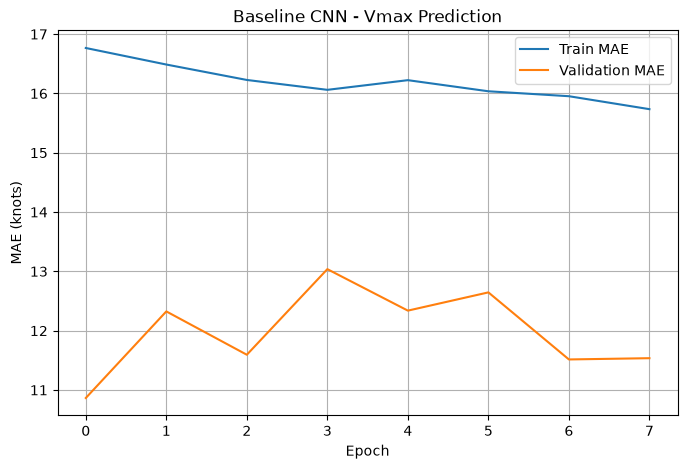

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    weighted_history.history["mae"],
    label="Train MAE"
)

plt.plot(
    weighted_history.history["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE (knots)")
plt.title("Baseline CNN - Vmax Prediction")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print(df[["ID", "time"]].head(20))

print("\nTime dtype:")
print(df["time"].dtype)

         ID        time
0   200301I  2003050818
1   200301I  2003050821
2   200301I  2003050900
3   200301I  2003050903
4   200301I  2003050906
5   200301I  2003050909
6   200301I  2003050912
7   200301I  2003050915
8   200301I  2003050918
9   200301I  2003050921
10  200301I  2003051000
11  200301I  2003051003
12  200301I  2003051006
13  200301I  2003051009
14  200301I  2003051012
15  200301I  2003051015
16  200301I  2003051018
17  200301I  2003051021
18  200301I  2003051100
19  200301I  2003051103

Time dtype:
int64


In [24]:
temp = df.copy()

temp["datetime"] = pd.to_datetime(
    temp["time"].astype(str),
    format="%Y%m%d%H",
    errors="coerce"
)

print("\nInvalid timestamps:", temp["datetime"].isna().sum())

print("\nExample cyclone:")
example_id = temp["ID"].iloc[0]

display(
    temp[temp["ID"] == example_id][
        ["ID", "time", "datetime", "Vmax", "lat", "lon", "matrix_index"]
    ].head(20)
)


Invalid timestamps: 0

Example cyclone:


,ID,time,datetime,Vmax,lat,lon,matrix_index
0,200301I,2003050818,2003-05-08 18:00:00,20.0,4.8,91.2,0
1,200301I,2003050821,2003-05-08 21:00:00,20.0,4.7,91.2,1
2,200301I,2003050900,2003-05-09 00:00:00,20.0,4.5,91.1,2
3,200301I,2003050903,2003-05-09 03:00:00,23.0,4.3,91.0,3
4,200301I,2003050906,2003-05-09 06:00:00,25.0,4.2,91.0,4
5,200301I,2003050909,2003-05-09 09:00:00,25.0,4.3,90.8,5
6,200301I,2003050912,2003-05-09 12:00:00,25.0,4.4,90.7,6
7,200301I,2003050915,2003-05-09 15:00:00,25.0,4.8,90.6,7
8,200301I,2003050918,2003-05-09 18:00:00,25.0,5.1,90.4,8
9,200301I,2003050921,2003-05-09 21:00:00,25.0,5.5,90.3,9


In [25]:
temp = temp.sort_values(
    ["ID", "datetime"]
)

temp["delta_hours"] = (
    temp.groupby("ID")["datetime"]
    .diff()
    .dt.total_seconds() / 3600
)

print(
    temp["delta_hours"]
    .value_counts()
    .sort_index()
)

delta_hours
3.0    3129
9.0       1
Name: count, dtype: int64


In [26]:
# --------------------------------------------------
# Temporal sequence configuration
# --------------------------------------------------

HISTORY_LENGTH = 5       # 5 frames = 15 hours
FORECAST_STEPS = 2       # 2 × 3 hours = +6 hours

SEQUENCE_GAP_HOURS = 3


def create_sequences(dataframe, history_length=5, forecast_steps=2):

    sequences = []

    data = dataframe.sort_values(
        ["ID", "datetime"]
    ).reset_index(drop=True)

    for cyclone_id, group in data.groupby("ID"):

        group = group.sort_values("datetime").reset_index(drop=True)

        n = len(group)

        # Need:
        # history_length frames
        # + forecast_steps into future
        for i in range(
            n - history_length - forecast_steps + 1
        ):

            history = group.iloc[
                i:i + history_length
            ]

            target_row = group.iloc[
                i + history_length + forecast_steps - 1
            ]

            # Check that all history frames are exactly 3h apart
            history_deltas = (
                history["datetime"]
                .diff()
                .dt.total_seconds()
                .div(3600)
                .dropna()
            )

            if not np.all(
                history_deltas.values == SEQUENCE_GAP_HOURS
            ):
                continue

            # Check history -> target spacing
            target_delta = (
                target_row["datetime"]
                - history.iloc[-1]["datetime"]
            ).total_seconds() / 3600

            if target_delta != (
                forecast_steps * SEQUENCE_GAP_HOURS
            ):
                continue

            sequences.append({
                "ID": cyclone_id,

                "input_indices": history[
                    "matrix_index"
                ].tolist(),

                "input_times": history[
                    "datetime"
                ].tolist(),

                "target_index": int(
                    target_row["matrix_index"]
                ),

                "target_time": target_row[
                    "datetime"
                ],

                "target_vmax": float(
                    target_row["Vmax"]
                ),

                "current_vmax": float(
                    history.iloc[-1]["Vmax"]
                ),

                "current_lat": float(
                    history.iloc[-1]["lat"]
                ),

                "current_lon": float(
                    history.iloc[-1]["lon"]
                )
            })

    return pd.DataFrame(sequences)


sequence_df = create_sequences(
    temp,
    history_length=HISTORY_LENGTH,
    forecast_steps=FORECAST_STEPS
)

print("Total temporal sequences:", len(sequence_df))
print("Unique cyclones:", sequence_df["ID"].nunique())

display(sequence_df.head())

Total temporal sequences: 2754
Unique cyclones: 75


,ID,input_indices,input_times,target_index,target_time,target_vmax,current_vmax,current_lat,current_lon
0,200301I,"[0, 1, 2, 3, 4]","[2003-05-08 18:00:00, 2003-05-08 21:00:00, 200...",6,2003-05-09 12:00:00,25.0,25.0,4.2,91.0
1,200301I,"[1, 2, 3, 4, 5]","[2003-05-08 21:00:00, 2003-05-09 00:00:00, 200...",7,2003-05-09 15:00:00,25.0,25.0,4.3,90.8
2,200301I,"[2, 3, 4, 5, 6]","[2003-05-09 00:00:00, 2003-05-09 03:00:00, 200...",8,2003-05-09 18:00:00,25.0,25.0,4.4,90.7
3,200301I,"[3, 4, 5, 6, 7]","[2003-05-09 03:00:00, 2003-05-09 06:00:00, 200...",9,2003-05-09 21:00:00,25.0,25.0,4.8,90.6
4,200301I,"[4, 5, 6, 7, 8]","[2003-05-09 06:00:00, 2003-05-09 09:00:00, 200...",10,2003-05-10 00:00:00,25.0,25.0,5.1,90.4


In [27]:
train_seq = sequence_df[
    sequence_df["ID"].isin(train_ids)
].reset_index(drop=True)

val_seq = sequence_df[
    sequence_df["ID"].isin(val_ids)
].reset_index(drop=True)

test_seq = sequence_df[
    sequence_df["ID"].isin(test_ids)
].reset_index(drop=True)

print("Train sequences:", len(train_seq))
print("Validation sequences:", len(val_seq))
print("Test sequences:", len(test_seq))

print("\nCyclones:")
print("Train:", train_seq["ID"].nunique())
print("Val  :", val_seq["ID"].nunique())
print("Test :", test_seq["ID"].nunique())

Train sequences: 2186
Validation sequences: 270
Test sequences: 298

Cyclones:
Train: 60
Val  : 7
Test : 8


In [28]:
TEMPORAL_BATCH_SIZE = 4

class TemporalTCIRSequence(
    tf.keras.utils.Sequence
):

    def __init__(
        self,
        h5_path,
        sequence_df,
        mean,
        std,
        batch_size=4,
        shuffle=True,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.h5_path = h5_path
        self.sequence_df = sequence_df.reset_index(
            drop=True
        )

        self.mean = mean.reshape(
            1, 1, 1, 4
        )

        self.std = std.reshape(
            1, 1, 1, 4
        )

        self.batch_size = batch_size
        self.shuffle = shuffle

        self.h5_file = None
        self.matrix = None

        self.order = np.arange(
            len(self.sequence_df)
        )

        self.on_epoch_end()

    def _open_file(self):

        if self.h5_file is None:

            self.h5_file = h5py.File(
                self.h5_path,
                "r"
            )

            self.matrix = self.h5_file["matrix"]

    def __len__(self):

        return int(
            np.ceil(
                len(self.sequence_df) /
                self.batch_size
            )
        )

    def __getitem__(self, batch_idx):

        self._open_file()

        start = (
            batch_idx *
            self.batch_size
        )

        end = min(
            start + self.batch_size,
            len(self.sequence_df)
        )

        batch_rows = self.order[
            start:end
        ]

        batch = self.sequence_df.iloc[
            batch_rows
        ]

        X = np.empty(
            (
                len(batch),
                HISTORY_LENGTH,
                201,
                201,
                4
            ),
            dtype=np.float32
        )

        y = np.empty(
            len(batch),
            dtype=np.float32
        )

        for j, (_, row) in enumerate(
            batch.iterrows()
        ):

            indices = np.asarray(
                row["input_indices"],
                dtype=np.int64
            )

            # HDF5 requires sorted indices
            order = np.argsort(indices)

            sorted_indices = indices[order]

            frames_sorted = np.asarray(
                self.matrix[
                    sorted_indices
                ],
                dtype=np.float32
            )

            frames = np.empty_like(
                frames_sorted
            )

            frames[order] = frames_sorted

            frames = np.nan_to_num(
                frames,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            frames = (
                frames - self.mean
            ) / self.std

            X[j] = frames

            y[j] = row["target_vmax"]

        return X, y

    def on_epoch_end(self):

        if self.shuffle:

            np.random.shuffle(
                self.order
            )

    def __del__(self):

        try:

            if self.h5_file is not None:
                self.h5_file.close()

        except Exception:
            pass

In [29]:
train_temporal_loader = TemporalTCIRSequence(
    H5_PATH,
    train_seq,
    channel_mean,
    channel_std,
    batch_size=TEMPORAL_BATCH_SIZE,
    shuffle=True
)

val_temporal_loader = TemporalTCIRSequence(
    H5_PATH,
    val_seq,
    channel_mean,
    channel_std,
    batch_size=TEMPORAL_BATCH_SIZE,
    shuffle=False
)

test_temporal_loader = TemporalTCIRSequence(
    H5_PATH,
    test_seq,
    channel_mean,
    channel_std,
    batch_size=TEMPORAL_BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_temporal_loader))
print("Val batches:", len(val_temporal_loader))
print("Test batches:", len(test_temporal_loader))

Train batches: 547
Val batches: 68
Test batches: 75


In [30]:
X_temp, y_temp = train_temporal_loader[0]

print("X shape:", X_temp.shape)
print("y shape:", y_temp.shape)

print("X dtype:", X_temp.dtype)
print("y dtype:", y_temp.dtype)

print("NaNs:", np.isnan(X_temp).sum())
print("Infs:", np.isinf(X_temp).sum())

X shape: (4, 5, 201, 201, 4)
y shape: (4,)
X dtype: float32
y dtype: float32
NaNs: 0
Infs: 0


In [31]:
from tensorflow.keras import layers, Model

def build_temporal_model():

    inputs = layers.Input(
        shape=(
            HISTORY_LENGTH,
            201,
            201,
            4
        )
    )

    # Shared spatial encoder
    frame_encoder = tf.keras.Sequential([

        layers.Conv2D(
            32,
            3,
            padding="same",
            activation="relu"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            64,
            3,
            padding="same",
            activation="relu"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            128,
            3,
            padding="same",
            activation="relu"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            256,
            3,
            padding="same",
            activation="relu"
        ),

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation="relu"
        )

    ], name="frame_encoder")

    # Apply same CNN to every timestep
    x = layers.TimeDistributed(
        frame_encoder
    )(inputs)

    # Learn temporal evolution
    x = layers.GRU(
        128,
        return_sequences=False
    )(x)

    x = layers.Dropout(0.3)(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    outputs = layers.Dense(
        1,
        name="future_vmax"
    )(x)

    return Model(
        inputs,
        outputs,
        name="TCIR_Temporal_CNN_GRU"
    )


temporal_model = build_temporal_model()

temporal_model.summary()

Model: "TCIR_Temporal_CNN_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 5, 201, 201, 4) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 128)         │       422,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ future_vmax (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,889 (2.02 MB)

 Trainable params: 529,441 (2.02 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
temporal_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=tf.keras.losses.Huber(
        delta=10.0
    ),

    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        ),
        tf.keras.metrics.RootMeanSquaredError(
            name="rmse"
        )
    ]
)

In [ ]:
temporal_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../models/temporal_cnn_gru_best.keras",
    monitor="val_mae",
    mode="min",
    save_best_only=True,
    verbose=1
)

temporal_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    mode="min",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

temporal_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_mae",
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
temporal_history = temporal_model.fit(
    train_temporal_loader,
    validation_data=val_temporal_loader,
    epochs=15,
    callbacks=[
        temporal_checkpoint,
        temporal_early_stop,
        temporal_reduce_lr
    ],
    verbose=1
)

Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 124.1074 - mae: 16.5495 - rmse: 26.0266
Epoch 1: val_mae improved from None to 9.95687, saving model to ../models/temporal_cnn_gru_best.keras

Epoch 1: finished saving model to ../models/temporal_cnn_gru_best.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 72s 84ms/step - loss: 124.1074 - mae: 16.5495 - rmse: 26.0266 - val_loss: 59.8320 - val_mae: 9.9569 - val_rmse: 13.4084 - learning_rate: 0.0010
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 115.0065 - mae: 15.5617 - rmse: 24.8206
Epoch 2: val_mae improved from 9.95687 to 9.84949, saving model to ../models/temporal_cnn_gru_best.keras

Epoch 2: finished saving model to ../models/temporal_cnn_gru_best.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 115.0065 - mae: 15.5617 - rmse: 24.8206 - val_loss: 59.0308 - val_mae: 9.8495 - val_rmse: 13.0610 - learning_rate: 0.0010
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 118.7178 - mae: 15.9488 - rmse: 25.395

In [ ]:
temporal_predictions = temporal_model.predict(
    test_temporal_loader,
    verbose=1
).flatten()

temporal_mae = mean_absolute_error(
    test_seq["target_vmax"].values,
    temporal_predictions
)

temporal_rmse = np.sqrt(
    mean_squared_error(
        test_seq["target_vmax"].values,
        temporal_predictions
    )
)

print("Temporal CNN + GRU")
print("MAE :", temporal_mae)
print("RMSE:", temporal_rmse)

75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step
Temporal CNN + GRU
MAE : 17.411013680016435
RMSE: 25.33769531021411


In [32]:
display(
    train_seq[
        [
            "ID",
            "input_times",
            "target_time",
            "current_vmax",
            "target_vmax"
        ]
    ].head(10)
)

,ID,input_times,target_time,current_vmax,target_vmax
0,200302I,"[2003-11-10 18:00:00, 2003-11-10 21:00:00, 200...",2003-11-11 12:00:00,15.0,15.0
1,200302I,"[2003-11-10 21:00:00, 2003-11-11 00:00:00, 200...",2003-11-11 15:00:00,15.0,15.0
2,200302I,"[2003-11-11 00:00:00, 2003-11-11 03:00:00, 200...",2003-11-11 18:00:00,15.0,15.0
3,200302I,"[2003-11-11 03:00:00, 2003-11-11 06:00:00, 200...",2003-11-11 21:00:00,15.0,18.0
4,200302I,"[2003-11-11 06:00:00, 2003-11-11 09:00:00, 200...",2003-11-12 00:00:00,15.0,20.0
5,200302I,"[2003-11-11 09:00:00, 2003-11-11 12:00:00, 200...",2003-11-12 03:00:00,18.0,23.0
6,200302I,"[2003-11-11 12:00:00, 2003-11-11 15:00:00, 200...",2003-11-12 06:00:00,20.0,25.0
7,200302I,"[2003-11-11 15:00:00, 2003-11-11 18:00:00, 200...",2003-11-12 09:00:00,23.0,28.0
8,200302I,"[2003-11-11 18:00:00, 2003-11-11 21:00:00, 200...",2003-11-12 12:00:00,25.0,30.0
9,200302I,"[2003-11-11 21:00:00, 2003-11-12 00:00:00, 200...",2003-11-12 15:00:00,28.0,38.0


In [ ]:
print(
    train_seq[
        "target_vmax"
    ].describe()
)

count    2186.000000
mean       43.429552
std        24.453474
min        15.000000
25%        28.000000
50%        35.000000
75%        50.000000
max       145.000000
Name: target_vmax, dtype: float64


In [33]:
def create_sequences_with_metadata(
    dataframe,
    history_length=5,
    forecast_steps=2
):

    sequences = []

    data = dataframe.sort_values(
        ["ID", "datetime"]
    ).reset_index(drop=True)

    for cyclone_id, group in data.groupby("ID"):

        group = group.sort_values(
            "datetime"
        ).reset_index(drop=True)

        n = len(group)

        for i in range(
            n - history_length - forecast_steps + 1
        ):

            history = group.iloc[
                i:i + history_length
            ]

            target = group.iloc[
                i + history_length + forecast_steps - 1
            ]

            # Check 3-hour spacing inside history
            deltas = (
                history["datetime"]
                .diff()
                .dt.total_seconds()
                / 3600
            ).dropna()

            if not np.all(deltas == 3):
                continue

            # Check history -> target spacing
            target_delta = (
                target["datetime"]
                - history.iloc[-1]["datetime"]
            ).total_seconds() / 3600

            if target_delta != 6:
                continue

            sequences.append({

                "ID": cyclone_id,

                "input_indices": history[
                    "matrix_index"
                ].tolist(),

                "vmax_history": history[
                    "Vmax"
                ].astype(float).tolist(),

                "lat_history": history[
                    "lat"
                ].astype(float).tolist(),

                "lon_history": history[
                    "lon"
                ].astype(float).tolist(),

                "target_vmax": float(
                    target["Vmax"]
                ),

                "target_lat": float(
                    target["lat"]
                ),

                "target_lon": float(
                    target["lon"]
                ),

                "target_time": target[
                    "datetime"
                ]
            })

    return pd.DataFrame(sequences)


sequence_df = create_sequences_with_metadata(
    temp,
    history_length=5,
    forecast_steps=2
)

print(
    "Total sequences:",
    len(sequence_df)
)

display(
    sequence_df[
        [
            "ID",
            "vmax_history",
            "lat_history",
            "lon_history",
            "target_vmax"
        ]
    ].head()
)

Total sequences: 2754


,ID,vmax_history,lat_history,lon_history,target_vmax
0,200301I,"[20.0, 20.0, 20.0, 23.0, 25.0]","[4.8, 4.7, 4.5, 4.3, 4.2]","[91.2, 91.2, 91.1, 91.0, 91.0]",25.0
1,200301I,"[20.0, 20.0, 23.0, 25.0, 25.0]","[4.7, 4.5, 4.3, 4.2, 4.3]","[91.2, 91.1, 91.0, 91.0, 90.8]",25.0
2,200301I,"[20.0, 23.0, 25.0, 25.0, 25.0]","[4.5, 4.3, 4.2, 4.3, 4.4]","[91.1, 91.0, 91.0, 90.8, 90.7]",25.0
3,200301I,"[23.0, 25.0, 25.0, 25.0, 25.0]","[4.3, 4.2, 4.3, 4.4, 4.8]","[91.0, 91.0, 90.8, 90.7, 90.6]",25.0
4,200301I,"[25.0, 25.0, 25.0, 25.0, 25.0]","[4.2, 4.3, 4.4, 4.8, 5.1]","[91.0, 90.8, 90.7, 90.6, 90.4]",25.0


In [34]:
train_seq = sequence_df[
    sequence_df["ID"].isin(train_ids)
].reset_index(drop=True)

val_seq = sequence_df[
    sequence_df["ID"].isin(val_ids)
].reset_index(drop=True)

test_seq = sequence_df[
    sequence_df["ID"].isin(test_ids)
].reset_index(drop=True)

print("Train:", len(train_seq))
print("Val:", len(val_seq))
print("Test:", len(test_seq))

Train: 2186
Val: 270
Test: 298


In [35]:
sample = train_seq.iloc[0]

print("Vmax history:", sample["vmax_history"])
print("Lat history :", sample["lat_history"])
print("Lon history :", sample["lon_history"])
print("Target Vmax :", sample["target_vmax"])
print("Target lat  :", sample["target_lat"])
print("Target lon  :", sample["target_lon"])

Vmax history: [15.0, 15.0, 15.0, 15.0, 15.0]
Lat history : [8.5, 8.4, 8.3, 8.2, 8.0]
Lon history : [66.4, 66.1, 65.7, 65.4, 65.1]
Target Vmax : 15.0
Target lat  : 7.6
Target lon  : 64.2


In [36]:
class MultimodalTCIRSequence(tf.keras.utils.Sequence):

    def __init__(
        self,
        h5_path,
        sequence_df,
        mean,
        std,
        meta_mean,
        meta_std,
        batch_size=4,
        shuffle=True,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.h5_path = h5_path
        self.sequence_df = sequence_df.reset_index(drop=True)

        self.mean = mean.reshape(1, 1, 1, 4)
        self.std = std.reshape(1, 1, 1, 4)

        self.meta_mean = meta_mean.astype(np.float32)
        self.meta_std = meta_std.astype(np.float32)

        self.batch_size = batch_size
        self.shuffle = shuffle

        self.h5_file = None
        self.matrix = None

        self.order = np.arange(len(self.sequence_df))

        self.on_epoch_end()

    def _open_file(self):

        if self.h5_file is None:

            self.h5_file = h5py.File(
                self.h5_path,
                "r"
            )

            self.matrix = self.h5_file["matrix"]

    def __len__(self):

        return int(
            np.ceil(
                len(self.sequence_df) /
                self.batch_size
            )
        )

    def __getitem__(self, batch_idx):

        self._open_file()

        start = batch_idx * self.batch_size
        end = min(
            start + self.batch_size,
            len(self.sequence_df)
        )

        batch_rows = self.order[start:end]

        batch = self.sequence_df.iloc[batch_rows]

        batch_size = len(batch)

        # Satellite data
        X_sat = np.empty(
            (
                batch_size,
                HISTORY_LENGTH,
                201,
                201,
                4
            ),
            dtype=np.float32
        )

        # Metadata
        X_meta = np.empty(
            (
                batch_size,
                HISTORY_LENGTH,
                3
            ),
            dtype=np.float32
        )

        # Target
        y = np.empty(
            batch_size,
            dtype=np.float32
        )

        for j, (_, row) in enumerate(
            batch.iterrows()
        ):

            # -------------------------
            # Satellite frames
            # -------------------------

            indices = np.asarray(
                row["input_indices"],
                dtype=np.int64
            )

            order = np.argsort(indices)

            sorted_indices = indices[order]

            frames_sorted = np.asarray(
                self.matrix[sorted_indices],
                dtype=np.float32
            )

            frames = np.empty_like(
                frames_sorted
            )

            frames[order] = frames_sorted

            frames = np.nan_to_num(
                frames,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            frames = (
                frames - self.mean
            ) / self.std

            X_sat[j] = frames

            # -------------------------
            # Metadata
            # -------------------------

            vmax = np.asarray(
                row["vmax_history"],
                dtype=np.float32
            )

            lat = np.asarray(
                row["lat_history"],
                dtype=np.float32
            )

            lon = np.asarray(
                row["lon_history"],
                dtype=np.float32
            )

            meta = np.stack(
                [vmax, lat, lon],
                axis=1
            )

            meta = (
                meta - self.meta_mean
            ) / self.meta_std

            X_meta[j] = meta

            # -------------------------
            # Target
            # -------------------------

            y[j] = row["target_vmax"]

        return {
            "satellite": X_sat,
            "metadata": X_meta
        }, y

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.order)

    def __del__(self):

        try:
            if self.h5_file is not None:
                self.h5_file.close()
        except Exception:
            pass

In [39]:
MULTIMODAL_BATCH_SIZE = 4

train_multi_loader = MultimodalTCIRSequence(
    H5_PATH,
    train_seq,
    channel_mean,
    channel_std,
    batch_size=MULTIMODAL_BATCH_SIZE,
    shuffle=True
)

val_multi_loader = MultimodalTCIRSequence(
    H5_PATH,
    val_seq,
    channel_mean,
    channel_std,
    batch_size=MULTIMODAL_BATCH_SIZE,
    shuffle=False
)

test_multi_loader = MultimodalTCIRSequence(
    H5_PATH,
    test_seq,
    channel_mean,
    channel_std,
    batch_size=MULTIMODAL_BATCH_SIZE,
    shuffle=False
)

TypeError: MultimodalTCIRSequence.__init__() missing 2 required positional arguments: 'meta_mean' and 'meta_std'

In [37]:
X_batch, y_batch = train_multi_loader[0]

print("Satellite shape:")
print(X_batch["satellite"].shape)

print("\nMetadata shape:")
print(X_batch["metadata"].shape)

print("\nTarget shape:")
print(y_batch.shape)

print("\nSatellite dtype:")
print(X_batch["satellite"].dtype)

print("\nMetadata dtype:")
print(X_batch["metadata"].dtype)

print("\nTarget:")
print(y_batch)

print("\nMetadata example:")
print(X_batch["metadata"][0])

NameError: name 'train_multi_loader' is not defined

In [40]:
# Collect training metadata
train_meta = np.array(
    train_seq[
        [
            "vmax_history",
            "lat_history",
            "lon_history"
        ]
    ].values.tolist(),
    dtype=np.float32
)

# Shape:
# (num_sequences, 3, 5)
print("Raw shape:", train_meta.shape)

# Convert to:
# (num_sequences, 5, 3)
train_meta = train_meta.transpose(0, 2, 1)

print("Rearranged shape:", train_meta.shape)

# Mean/std over sequences and time
meta_mean = train_meta.mean(axis=(0, 1))
meta_std = train_meta.std(axis=(0, 1))

# Prevent division by zero
meta_std = np.maximum(meta_std, 1e-6)

print("Metadata mean:", meta_mean)
print("Metadata std :", meta_std)

Raw shape: (2186, 3, 5)
Rearranged shape: (2186, 5, 3)
Metadata mean: [42.913906 13.134866 76.54612 ]
Metadata std : [24.361696  4.63445  13.00397 ]


In [41]:
train_multi_loader = MultimodalTCIRSequence(
    H5_PATH,
    train_seq,
    channel_mean,
    channel_std,
    meta_mean,
    meta_std,
    batch_size=4,
    shuffle=True
)

val_multi_loader = MultimodalTCIRSequence(
    H5_PATH,
    val_seq,
    channel_mean,
    channel_std,
    meta_mean,
    meta_std,
    batch_size=4,
    shuffle=False
)

test_multi_loader = MultimodalTCIRSequence(
    H5_PATH,
    test_seq,
    channel_mean,
    channel_std,
    meta_mean,
    meta_std,
    batch_size=4,
    shuffle=False
)

In [42]:
X_batch, y_batch = train_multi_loader[0]

print("Metadata after normalization:")
print(X_batch["metadata"][0])

print("\nMean approximately:")
print(X_batch["metadata"].mean(axis=(0, 1)))

print("\nStd approximately:")
print(X_batch["metadata"].std(axis=(0, 1)))

Metadata after normalization:
[[-0.5300906  -0.05067832 -0.3957344 ]
 [-0.5300906  -0.05067832 -0.40342423]
 [-0.5300906  -0.00752309 -0.41111466]
 [-0.5300906   0.01405432 -0.4188045 ]
 [-0.5300906   0.03563194 -0.42649433]]

Mean approximately:
[-0.6614442   0.43265852  0.38979486]

Std approximately:
[0.20176274 1.1841801  0.99685806]


In [43]:
from tensorflow.keras import layers, Model


def build_multimodal_model():

    # =========================================
    # Satellite input
    # (5, 201, 201, 4)
    # =========================================

    satellite_input = layers.Input(
        shape=(HISTORY_LENGTH, 201, 201, 4),
        name="satellite"
    )

    # Shared CNN for each satellite frame
    frame_encoder = tf.keras.Sequential([

        layers.Conv2D(
            32, 3,
            padding="same",
            activation="relu"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            64, 3,
            padding="same",
            activation="relu"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            128, 3,
            padding="same",
            activation="relu"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            256, 3,
            padding="same",
            activation="relu"
        ),

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation="relu"
        )

    ], name="satellite_encoder")

    # Apply CNN independently to each timestep
    sat_features = layers.TimeDistributed(
        frame_encoder,
        name="time_distributed_cnn"
    )(satellite_input)

    # Learn satellite evolution
    sat_temporal = layers.GRU(
        128,
        return_sequences=False,
        name="satellite_gru"
    )(sat_features)


    # =========================================
    # Metadata input
    # (5, 3)
    # =========================================

    metadata_input = layers.Input(
        shape=(HISTORY_LENGTH, 3),
        name="metadata"
    )

    # Small feature projection
    meta_features = layers.TimeDistributed(
        layers.Dense(
            32,
            activation="relu"
        )
    )(metadata_input)

    # Learn metadata evolution
    meta_temporal = layers.GRU(
        32,
        return_sequences=False,
        name="metadata_gru"
    )(meta_features)


    # =========================================
    # Fusion
    # =========================================

    fusion = layers.Concatenate(
        name="multimodal_fusion"
    )([
        sat_temporal,
        meta_temporal
    ])

    fusion = layers.Dense(
        128,
        activation="relu"
    )(fusion)

    fusion = layers.Dropout(
        0.3
    )(fusion)

    fusion = layers.Dense(
        64,
        activation="relu"
    )(fusion)

    # Future Vmax
    output = layers.Dense(
        1,
        name="future_vmax"
    )(fusion)


    return Model(
        inputs=[
            satellite_input,
            metadata_input
        ],
        outputs=output,
        name="Multimodal_Cyclone_Model"
    )


multimodal_model = build_multimodal_model()

multimodal_model.summary()

Model: "Multimodal_Cyclone_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ satellite           │ (None, 5, 201,    │          0 │ -                 │
│ (InputLayer)        │ 201, 4)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 5, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_c… │ (None, 5, 128)    │    422,496 │ satellite[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 5, 32)     │        128 │ metadata[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ satellite_gru (GRU) │ (None, 128)       │     99,072 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_gru (GRU)  │ (None, 32)        │      6,336 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multimodal_fusion   │ (None, 160)       │          0 │ satellite_gru[0]… │
│ (Concatenate)       │                   │            │ metadata_gru[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     20,608 │ multimodal_fusio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_vmax (Dense) │ (None, 1)         │         65 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 556,961 (2.12 MB)

 Trainable params: 556,513 (2.12 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
multimodal_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=tf.keras.losses.Huber(
        delta=10.0
    ),

    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        ),
        tf.keras.metrics.RootMeanSquaredError(
            name="rmse"
        )
    ]
)

In [ ]:
loss, mae_test, rmse_test = multimodal_model.evaluate(
    train_multi_loader,
    steps=1,
    verbose=1
)

print("Smoke test successful")
print("Loss:", loss)
print("MAE:", mae_test)
print("RMSE:", rmse_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step - loss: 368.6743 - mae: 41.8674 - rmse: 44.0158
Smoke test successful
Loss: 368.67425537109375
MAE: 41.86742401123047
RMSE: 44.01580047607422


In [ ]:
multimodal_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../models/multimodal_cnn_gru_best.keras",
    monitor="val_mae",
    mode="min",
    save_best_only=True,
    verbose=1
)

multimodal_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    mode="min",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

multimodal_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_mae",
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
multimodal_history = multimodal_model.fit(
    train_multi_loader,
    validation_data=val_multi_loader,
    epochs=15,
    callbacks=[
        multimodal_checkpoint,
        multimodal_early_stop,
        multimodal_reduce_lr
    ],
    verbose=1
)

Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 53.2768 - mae: 8.7166 - rmse: 14.9003
Epoch 1: val_mae improved from None to 3.70315, saving model to ../models/multimodal_cnn_gru_best.keras

Epoch 1: finished saving model to ../models/multimodal_cnn_gru_best.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - loss: 53.2768 - mae: 8.7166 - rmse: 14.9003 - val_loss: 10.7946 - val_mae: 3.7032 - val_rmse: 4.6655 - learning_rate: 0.0010
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 20.7454 - mae: 5.0304 - rmse: 7.0244
Epoch 2: val_mae improved from 3.70315 to 2.84919, saving model to ../models/multimodal_cnn_gru_best.keras

Epoch 2: finished saving model to ../models/multimodal_cnn_gru_best.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 45s 82ms/step - loss: 20.7454 - mae: 5.0304 - rmse: 7.0244 - val_loss: 7.1674 - val_mae: 2.8492 - val_rmse: 3.8010 - learning_rate: 0.0010
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 18.5706 - mae: 4.6753 - rmse: 6.5822
Epoch 

In [49]:
multimodal_predictions = multimodal_model.predict(
    test_multi_loader,
    verbose=1
).flatten()

y_test_multi = test_seq[
    "target_vmax"
].values

multimodal_mae = mean_absolute_error(
    y_test_multi,
    multimodal_predictions
)

multimodal_rmse = np.sqrt(
    mean_squared_error(
        y_test_multi,
        multimodal_predictions
    )
)

print("\nMultimodal CNN + GRU")
print("MAE :", multimodal_mae)
print("RMSE:", multimodal_rmse)

75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step

Multimodal CNN + GRU
MAE : 45.12206982237431
RMSE: 51.361925729990205


In [50]:
comparison = pd.DataFrame({
    "Actual": y_test_multi,
    "Predicted": multimodal_predictions
})

comparison["Absolute_Error"] = np.abs(
    comparison["Actual"] -
    comparison["Predicted"]
)

comparison["Intensity_Bin"] = pd.cut(
    comparison["Actual"],
    bins=[0, 25, 35, 50, 65, 200],
    labels=[
        "15-25",
        "26-35",
        "36-50",
        "51-65",
        "66+"
    ]
)

display(
    comparison
    .groupby(
        "Intensity_Bin",
        observed=True
    )
    .agg(
        Samples=("Actual", "count"),
        MAE=("Absolute_Error", "mean"),
        Actual_Mean=("Actual", "mean"),
        Predicted_Mean=("Predicted", "mean")
    )
)

,Samples,MAE,Actual_Mean,Predicted_Mean
Intensity_Bin,,,,
15-25,70,22.217630,22.300000,0.082370
26-35,76,31.804245,31.881579,0.077334
36-50,67,43.692335,43.776119,0.083784
51-65,38,57.805609,57.868421,0.062812
66+,47,92.553628,92.595745,0.042117


In [51]:
persistence_predictions = test_seq[
    "vmax_history"
].apply(lambda x: x[-1]).values.astype(np.float32)

y_test_multi = test_seq[
    "target_vmax"
].values.astype(np.float32)

persistence_mae = mean_absolute_error(
    y_test_multi,
    persistence_predictions
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        y_test_multi,
        persistence_predictions
    )
)

print("Persistence baseline")
print("MAE :", persistence_mae)
print("RMSE:", persistence_rmse)

print("\nMultimodal CNN + GRU")
print("MAE :", multimodal_mae)
print("RMSE:", multimodal_rmse)

Persistence baseline
MAE : 5.2718119621276855
RMSE: 8.282146822753889

Multimodal CNN + GRU
MAE : 45.12206982237431
RMSE: 51.361925729990205


In [98]:
def trend_prediction(history):

    history = np.asarray(
        history,
        dtype=np.float32
    )

    return (
        history[-1]
        +
        (history[-1] - history[0])
        * (6.0 / 12.0)
    )


trend_predictions = np.array([
    trend_prediction(x)
    for x in test_seq["vmax_history"]
])

trend_mae = mean_absolute_error(
    y_test_multi,
    trend_predictions
)

trend_rmse = np.sqrt(
    mean_squared_error(
        y_test_multi,
        trend_predictions
    )
)

print("Trend baseline")
print("MAE :", trend_mae)
print("RMSE:", trend_rmse)

Trend baseline
MAE : 4.21308708190918
RMSE: 8.04616482758197


In [99]:
def make_metadata_array(df):

    return np.array([
        np.stack([
            row["vmax_history"],
            row["lat_history"],
            row["lon_history"]
        ], axis=1)
        for _, row in df.iterrows()
    ], dtype=np.float32)


X_meta_train = make_metadata_array(train_seq)
X_meta_val = make_metadata_array(val_seq)
X_meta_test = make_metadata_array(test_seq)

y_meta_train = train_seq["target_vmax"].values.astype(np.float32)
y_meta_val = val_seq["target_vmax"].values.astype(np.float32)
y_meta_test = test_seq["target_vmax"].values.astype(np.float32)

print("Train:", X_meta_train.shape)
print("Val  :", X_meta_val.shape)
print("Test :", X_meta_test.shape)

Train: (2186, 5, 3)
Val  : (270, 5, 3)
Test : (298, 5, 3)


In [100]:
X_meta_train = (
    X_meta_train - meta_mean
) / meta_std

X_meta_val = (
    X_meta_val - meta_mean
) / meta_std

X_meta_test = (
    X_meta_test - meta_mean
) / meta_std

In [101]:
meta_input = tf.keras.Input(
    shape=(HISTORY_LENGTH, 3),
    name="metadata"
)

x = tf.keras.layers.GRU(
    64,
    return_sequences=True
)(meta_input)

x = tf.keras.layers.GRU(
    32
)(x)

x = tf.keras.layers.Dense(
    64,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.2)(x)

x = tf.keras.layers.Dense(
    32,
    activation="relu"
)(x)

meta_output = tf.keras.layers.Dense(
    1,
    name="future_vmax"
)(x)

metadata_model = tf.keras.Model(
    meta_input,
    meta_output,
    name="Metadata_Only_GRU"
)

metadata_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.Huber(
        delta=10.0
    ),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        ),
        tf.keras.metrics.RootMeanSquaredError(
            name="rmse"
        )
    ]
)

metadata_model.summary()

Model: "Metadata_Only_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ metadata (InputLayer)           │ (None, 5, 3)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 5, 64)          │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ future_vmax (Dense)             │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,881 (105.00 KB)

 Trainable params: 26,881 (105.00 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
metadata_history = metadata_model.fit(
    X_meta_train,
    y_meta_train,

    validation_data=(
        X_meta_val,
        y_meta_val
    ),

    epochs=30,

    batch_size=32,

    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_mae",
            patience=6,
            mode="min",
            restore_best_weights=True
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_mae",
            patience=3,
            factor=0.5,
            min_lr=1e-6,
            mode="min"
        )
    ],

    verbose=1
)

Epoch 1/30


KeyboardInterrupt: 

In [102]:
metadata_predictions = (
    metadata_model
    .predict(
        X_meta_test,
        verbose=1
    )
    .flatten()
)

metadata_mae = mean_absolute_error(
    y_meta_test,
    metadata_predictions
)

metadata_rmse = np.sqrt(
    mean_squared_error(
        y_meta_test,
        metadata_predictions
    )
)

print("\nMetadata-only GRU")
print("MAE :", metadata_mae)
print("RMSE:", metadata_rmse)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

Metadata-only GRU
MAE : 45.16180419921875
RMSE: 51.39248010865743


In [103]:
train_seq["delta_lat"] = (
    train_seq["target_lat"] -
    train_seq["lat_history"].apply(lambda x: x[-1])
)

train_seq["delta_lon"] = (
    train_seq["target_lon"] -
    train_seq["lon_history"].apply(lambda x: x[-1])
)

val_seq["delta_lat"] = (
    val_seq["target_lat"] -
    val_seq["lat_history"].apply(lambda x: x[-1])
)

val_seq["delta_lon"] = (
    val_seq["target_lon"] -
    val_seq["lon_history"].apply(lambda x: x[-1])
)

test_seq["delta_lat"] = (
    test_seq["target_lat"] -
    test_seq["lat_history"].apply(lambda x: x[-1])
)

test_seq["delta_lon"] = (
    test_seq["target_lon"] -
    test_seq["lon_history"].apply(lambda x: x[-1])
)

print("Train Δlat:")
print(train_seq["delta_lat"].describe())

print("\nTrain Δlon:")
print(train_seq["delta_lon"].describe())

Train Δlat:
count    2186.000000
mean        0.230192
std         0.410930
min        -1.500000
25%         0.000000
50%         0.200000
75%         0.500000
max         2.400000
Name: delta_lat, dtype: float64

Train Δlon:
count    2186.000000
mean       -0.380512
std         0.545919
min        -2.400000
25%        -0.700000
50%        -0.400000
75%        -0.100000
max         3.200000
Name: delta_lon, dtype: float64


In [104]:
import numpy as np

# Current position = last position in the 5-frame history
test_seq["current_lat"] = test_seq["lat_history"].apply(lambda x: x[-1])
test_seq["current_lon"] = test_seq["lon_history"].apply(lambda x: x[-1])

# --------------------------------------------------
# 1. Persistence baseline
# --------------------------------------------------
# Predict zero displacement
test_seq["pred_delta_lat_persistence"] = 0.0
test_seq["pred_delta_lon_persistence"] = 0.0

test_seq["pred_lat_persistence"] = (
    test_seq["current_lat"] +
    test_seq["pred_delta_lat_persistence"]
)

test_seq["pred_lon_persistence"] = (
    test_seq["current_lon"] +
    test_seq["pred_delta_lon_persistence"]
)

# --------------------------------------------------
# 2. Velocity / trend baseline
# --------------------------------------------------
# History is 5 frames, each ~3 hours apart.
# Forecast is 6 hours = 2 time steps.
#
# So:
# predicted displacement = last 3-hour displacement * 2

test_seq["last_dlat"] = test_seq["lat_history"].apply(
    lambda x: x[-1] - x[-2]
)

test_seq["last_dlon"] = test_seq["lon_history"].apply(
    lambda x: x[-1] - x[-2]
)

test_seq["pred_delta_lat_trend"] = 2 * test_seq["last_dlat"]
test_seq["pred_delta_lon_trend"] = 2 * test_seq["last_dlon"]

test_seq["pred_lat_trend"] = (
    test_seq["current_lat"] +
    test_seq["pred_delta_lat_trend"]
)

test_seq["pred_lon_trend"] = (
    test_seq["current_lon"] +
    test_seq["pred_delta_lon_trend"]
)

# --------------------------------------------------
# Haversine distance
# --------------------------------------------------
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


# Persistence error
test_seq["persistence_error_km"] = haversine_km(
    test_seq["target_lat"],
    test_seq["target_lon"],
    test_seq["pred_lat_persistence"],
    test_seq["pred_lon_persistence"]
)

# Trend error
test_seq["trend_error_km"] = haversine_km(
    test_seq["target_lat"],
    test_seq["target_lon"],
    test_seq["pred_lat_trend"],
    test_seq["pred_lon_trend"]
)

print("Track baselines:")
print(
    "Persistence MAE:",
    test_seq["persistence_error_km"].mean(),
    "km"
)

print(
    "Trend MAE:",
    test_seq["trend_error_km"].mean(),
    "km"
)

Track baselines:
Persistence MAE: 63.991348714495935 km
Trend MAE: 27.757192863339924 km


In [105]:
import numpy as np
import tensorflow as tf
import h5py


# --------------------------------------------------
# Track target statistics
# --------------------------------------------------

train_dlat = train_seq["delta_lat"].values.astype(np.float32)
train_dlon = train_seq["delta_lon"].values.astype(np.float32)

track_mean = np.array([
    train_dlat.mean(),
    train_dlon.mean()
], dtype=np.float32)

track_std = np.array([
    train_dlat.std(),
    train_dlon.std()
], dtype=np.float32)

print("Track target mean:", track_mean)
print("Track target std :", track_std)


# --------------------------------------------------
# Track Sequence
# --------------------------------------------------

class TrackSequence(tf.keras.utils.Sequence):

    def __init__(
        self,
        seq_df,
        h5_path,
        batch_size=32,
        shuffle=False
    ):
        self.df = seq_df.reset_index(drop=True)
        self.h5_path = h5_path
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.indices = np.arange(len(self.df))

        self.h5_file = None

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indices)

    def _open_file(self):

        if self.h5_file is None:
            self.h5_file = h5py.File(self.h5_path, "r")

    def __getitem__(self, idx):

        self._open_file()

        batch_indices = self.indices[
            idx * self.batch_size:
            min((idx + 1) * self.batch_size, len(self.indices))
        ]

        batch = self.df.iloc[batch_indices]

        # ------------------------------------------
        # Satellite indices
        # ------------------------------------------

        sat_indices = np.array(
            [x for row in batch["input_indices"] for x in row],
            dtype=np.int64
        )

        # HDF5 fancy indexing requires sorted indices
        order = np.argsort(sat_indices)

        sorted_indices = sat_indices[order]

        images_sorted = self.h5_file["matrix"][
            sorted_indices
        ]

        inverse_order = np.argsort(order)

        images = images_sorted[inverse_order]

        # ------------------------------------------
        # Reshape:
        # (batch * history, H, W, C)
        # ->
        # (batch, history, H, W, C)
        # ------------------------------------------

        images = images.reshape(
            len(batch),
            5,
            201,
            201,
            4
        ).astype(np.float32)

        # Replace NaN / Inf
        images = np.nan_to_num(images)

        # ------------------------------------------
        # Metadata
        #
        # Vmax, latitude, longitude
        # ------------------------------------------

        metadata = np.array(
            [
                [
                    [
                        row["vmax_history"][t],
                        row["lat_history"][t],
                        row["lon_history"][t]
                    ]
                    for t in range(5)
                ]
                for _, row in batch.iterrows()
            ],
            dtype=np.float32
        )

        # Normalize using TRAIN statistics
        metadata = (
            metadata - meta_mean
        ) / meta_std

        # ------------------------------------------
        # Track target
        # ------------------------------------------

        targets = np.array(
            [
                [row["delta_lat"], row["delta_lon"]]
                for _, row in batch.iterrows()
            ],
            dtype=np.float32
        )

        targets = (
            targets - track_mean
        ) / track_std

        return (
            {
                "satellite": images,
                "metadata": metadata
            },
            targets
        )

Track target mean: [ 0.23019212 -0.38051236]
Track target std : [0.41083637 0.54579395]


In [106]:
H5_PATH = "../data/tcir_io.h5"

train_track_loader = TrackSequence(
    train_seq,
    H5_PATH,
    batch_size=32,
    shuffle=True
)

val_track_loader = TrackSequence(
    val_seq,
    H5_PATH,
    batch_size=32,
    shuffle=False
)

test_track_loader = TrackSequence(
    test_seq,
    H5_PATH,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_track_loader))
print("Val batches  :", len(val_track_loader))
print("Test batches :", len(test_track_loader))

Train batches: 69
Val batches  : 9
Test batches : 10


In [61]:
x, y = train_track_loader[0]

print("Satellite shape:", x["satellite"].shape)
print("Metadata shape :", x["metadata"].shape)
print("Target shape   :", y.shape)

TypeError: Indexing elements must be in increasing order

In [62]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir("."))

print("\nDoes data/tcir_io.h5 exist?")
print(os.path.exists("data/tcir_io.h5"))

print("\nAbsolute path:")
print(os.path.abspath("data/tcir_io.h5"))

Current working directory:
/home/vishal/CycloneAI/notebooks

Files in current directory:
['01_tcir_exploration.ipynb', '02_baseline_cnn.ipynb']

Does data/tcir_io.h5 exist?
False

Absolute path:
/home/vishal/CycloneAI/notebooks/data/tcir_io.h5


In [107]:
H5_PATH = "../data/tcir_io.h5"

train_track_loader = TrackSequence(
    train_seq,
    H5_PATH,
    batch_size=32,
    shuffle=True
)

val_track_loader = TrackSequence(
    val_seq,
    H5_PATH,
    batch_size=32,
    shuffle=False
)

test_track_loader = TrackSequence(
    test_seq,
    H5_PATH,
    batch_size=32,
    shuffle=False
)


In [ ]:
x, y = train_track_loader[0]

print("Satellite shape:", x["satellite"].shape)
print("Metadata shape :", x["metadata"].shape)
print("Target shape   :", y.shape)

TypeError: Indexing elements must be in increasing order

In [108]:
class TrackSequence(tf.keras.utils.Sequence):

    def __init__(
        self,
        seq_df,
        h5_path,
        batch_size=32,
        shuffle=False
    ):
        self.df = seq_df.reset_index(drop=True)
        self.h5_path = h5_path
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.indices = np.arange(len(self.df))
        self.h5_file = None

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def _open_file(self):
        if self.h5_file is None:
            self.h5_file = h5py.File(self.h5_path, "r")

    def __getitem__(self, idx):

        self._open_file()

        batch_indices = self.indices[
            idx * self.batch_size:
            min((idx + 1) * self.batch_size, len(self.indices))
        ]

        batch = self.df.iloc[batch_indices]

        # ------------------------------------------------
        # Satellite data
        # ------------------------------------------------

        images = np.empty(
            (len(batch), 5, 201, 201, 4),
            dtype=np.float32
        )

        for b, (_, row) in enumerate(batch.iterrows()):

            for t, matrix_idx in enumerate(row["input_indices"]):

                # Read ONE frame at a time.
                images[b, t] = self.h5_file["matrix"][int(matrix_idx)]

        # Replace NaN / Inf
        images = np.nan_to_num(images)

        # ------------------------------------------------
        # Metadata
        # Vmax, latitude, longitude
        # ------------------------------------------------

        metadata = np.array(
            [
                [
                    [
                        row["vmax_history"][t],
                        row["lat_history"][t],
                        row["lon_history"][t]
                    ]
                    for t in range(5)
                ]
                for _, row in batch.iterrows()
            ],
            dtype=np.float32
        )

        # Normalize using training statistics
        metadata = (
            metadata - meta_mean
        ) / meta_std

        # ------------------------------------------------
        # Target
        # [delta_lat, delta_lon]
        # ------------------------------------------------

        targets = np.array(
            [
                [
                    row["delta_lat"],
                    row["delta_lon"]
                ]
                for _, row in batch.iterrows()
            ],
            dtype=np.float32
        )

        # Normalize targets
        targets = (
            targets - track_mean
        ) / track_std

        return (
            {
                "satellite": images,
                "metadata": metadata
            },
            targets
        )

In [109]:
H5_PATH = "../data/tcir_io.h5"

train_track_loader = TrackSequence(
    train_seq,
    H5_PATH,
    batch_size=32,
    shuffle=True
)

val_track_loader = TrackSequence(
    val_seq,
    H5_PATH,
    batch_size=32,
    shuffle=False
)

test_track_loader = TrackSequence(
    test_seq,
    H5_PATH,
    batch_size=32,
    shuffle=False
)

In [65]:
x, y = train_track_loader[0]

print("Satellite shape:", x["satellite"].shape)
print("Metadata shape :", x["metadata"].shape)
print("Target shape   :", y.shape)

print("\nFirst target:")
print(y[0])

TypeError: Indexing elements must be in increasing order

In [110]:
import tensorflow as tf
from tensorflow.keras import layers, Model


# ============================================================
# Satellite CNN encoder
# ============================================================

sat_input = layers.Input(
    shape=(5, 201, 201, 4),
    name="satellite"
)

x = layers.TimeDistributed(
    layers.Conv2D(32, 3, padding="same", activation="relu")
)(sat_input)

x = layers.TimeDistributed(
    layers.MaxPooling2D(2)
)(x)

x = layers.TimeDistributed(
    layers.Conv2D(64, 3, padding="same", activation="relu")
)(x)

x = layers.TimeDistributed(
    layers.MaxPooling2D(2)
)(x)

x = layers.TimeDistributed(
    layers.Conv2D(128, 3, padding="same", activation="relu")
)(x)

x = layers.TimeDistributed(
    layers.MaxPooling2D(2)
)(x)

x = layers.TimeDistributed(
    layers.Conv2D(256, 3, padding="same", activation="relu")
)(x)

x = layers.TimeDistributed(
    layers.GlobalAveragePooling2D()
)(x)

# Temporal satellite representation
sat_features = layers.GRU(
    128,
    return_sequences=False,
    name="satellite_gru"
)(x)


# ============================================================
# Metadata branch
# ============================================================

meta_input = layers.Input(
    shape=(5, 3),
    name="metadata"
)

m = layers.TimeDistributed(
    layers.Dense(32, activation="relu")
)(meta_input)

m = layers.GRU(
    32,
    return_sequences=False,
    name="metadata_gru"
)(m)


# ============================================================
# Fusion
# ============================================================

fused = layers.Concatenate()([
    sat_features,
    m
])

fused = layers.Dense(
    128,
    activation="relu"
)(fused)

fused = layers.Dropout(0.3)(fused)

fused = layers.Dense(
    64,
    activation="relu"
)(fused)


# ============================================================
# Track prediction
# ============================================================

output = layers.Dense(
    2,
    name="track_displacement"
)(fused)


track_model = Model(
    inputs={
        "satellite": sat_input,
        "metadata": meta_input
    },
    outputs=output
)


track_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ satellite           │ (None, 5, 201,    │          0 │ -                 │
│ (InputLayer)        │ 201, 4)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_16 │ (None, 5, 201,    │      1,184 │ satellite[0][0]   │
│ (TimeDistributed)   │ 201, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_17 │ (None, 5, 100,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 100, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_18 │ (None, 5, 100,    │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 100, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_19 │ (None, 5, 50, 50, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_20 │ (None, 5, 50, 50, │     73,856 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_21 │ (None, 5, 25, 25, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_22 │ (None, 5, 25, 25, │    295,168 │ time_distributed… │
│ (TimeDistributed)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 5, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_23 │ (None, 5, 256)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_24 │ (None, 5, 32)     │        128 │ metadata[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ satellite_gru (GRU) │ (None, 128)       │    148,224 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_gru (GRU)  │ (None, 32)        │      6,336 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 160)       │          0 │ satellite_gru[0]… │
│ (Concatenate)       │                   │            │ metadata_gru[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │     20,608 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ track_displacement  │ (None, 2)         │        130 │ dense_13[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 572,386 (2.18 MB)

 Trainable params: 572,386 (2.18 MB)

 Non-trainable params: 0 (0.00 B)

In [111]:
track_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.Huber(),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history_track = track_model.fit(
    train_track_loader,
    validation_data=val_track_loader,
    epochs=30,
    callbacks=callbacks
)

/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


W0000 00:00:1788829945.510863    9744 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 789.08MiB (rounded to 827412480)requested by op StatefulPartitionedCall/gradient_tape/functional_4_1/time_distributed_3_1/strided_slice_4/StridedSliceGrad
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1788829945.518213    9744 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1788829945.518221    9744 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 508, Chunks in use: 506. 127.0KiB allocated for chunks. 126.5KiB in use in bin. 25.8KiB client-requested in use in bin.
I0000 00:00:1788829945.518229    9744 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 94, Chunks in use: 89. 51.5KiB allocated for chunks. 48.2KiB in use in bin. 45.8KiB client-requested in use in bin.
I0000 00:00:17888

ResourceExhaustedError: Graph execution error:

Detected at node gradient_tape/functional_4_1/time_distributed_3_1/strided_slice_4/StridedSliceGrad defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1080, in launch_instance

  File "/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 807, in start

  File "/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/vishal/.pyenv/versions/3.12.11/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/home/vishal/.pyenv/versions/3.12.11/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/home/vish

In [112]:
# Get normalized predictions
pred_norm = track_model.predict(
    test_track_loader,
    verbose=1
)

# Convert back to degrees
pred_delta = (
    pred_norm * track_std
    + track_mean
)

pred_delta_lat = pred_delta[:, 0]
pred_delta_lon = pred_delta[:, 1]

# Current positions
current_lat = test_seq["lat_history"].apply(
    lambda x: x[-1]
).values

current_lon = test_seq["lon_history"].apply(
    lambda x: x[-1]
).values

# Predicted future position
pred_lat = current_lat + pred_delta_lat
pred_lon = current_lon + pred_delta_lon

# Actual future position
actual_lat = test_seq["target_lat"].values
actual_lon = test_seq["target_lon"].values

/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


KeyboardInterrupt: 

In [113]:
def haversine_km(lat1, lon1, lat2, lon2):

    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)

    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2)**2
    )

    return 2 * R * np.arcsin(
        np.sqrt(a)
    )


track_error = haversine_km(
    actual_lat,
    actual_lon,
    pred_lat,
    pred_lon
)

print("================================")
print("6-Hour Track Prediction")
print("================================")

print(
    f"MAE: {track_error.mean():.2f} km"
)

print(
    f"Median Error: {np.median(track_error):.2f} km"
)

print(
    f"RMSE: {np.sqrt(np.mean(track_error**2)):.2f} km"
)

print(
    f"90th Percentile: {np.percentile(track_error, 90):.2f} km"
)

6-Hour Track Prediction
MAE: 27.24 km
Median Error: 20.41 km
RMSE: 35.55 km
90th Percentile: 49.39 km


In [114]:
import tensorflow as tf
import gc

tf.keras.backend.clear_session()
gc.collect()

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [115]:
H5_PATH = "../data/tcir_io.h5"

train_track_loader = TrackSequence(
    train_seq,
    H5_PATH,
    batch_size=8,
    shuffle=True
)

val_track_loader = TrackSequence(
    val_seq,
    H5_PATH,
    batch_size=8,
    shuffle=False
)

test_track_loader = TrackSequence(
    test_seq,
    H5_PATH,
    batch_size=8,
    shuffle=False
)

print("Train batches:", len(train_track_loader))
print("Val batches:", len(val_track_loader))
print("Test batches:", len(test_track_loader))

Train batches: 274
Val batches: 34
Test batches: 38


In [116]:
from tensorflow.keras import layers, Model

sat_input = layers.Input(
    shape=(5, 201, 201, 4),
    name="satellite"
)

# --------------------------------------------
# Satellite encoder
# --------------------------------------------

x = layers.TimeDistributed(
    layers.Conv2D(16, 3, padding="same", activation="relu")
)(sat_input)

x = layers.TimeDistributed(
    layers.MaxPooling2D(2)
)(x)

x = layers.TimeDistributed(
    layers.Conv2D(32, 3, padding="same", activation="relu")
)(x)

x = layers.TimeDistributed(
    layers.MaxPooling2D(2)
)(x)

x = layers.TimeDistributed(
    layers.Conv2D(64, 3, padding="same", activation="relu")
)(x)

x = layers.TimeDistributed(
    layers.MaxPooling2D(2)
)(x)

x = layers.TimeDistributed(
    layers.GlobalAveragePooling2D()
)(x)

sat_features = layers.GRU(
    64,
    name="satellite_gru"
)(x)


# --------------------------------------------
# Metadata branch
# --------------------------------------------

meta_input = layers.Input(
    shape=(5, 3),
    name="metadata"
)

m = layers.TimeDistributed(
    layers.Dense(16, activation="relu")
)(meta_input)

m = layers.GRU(
    16,
    name="metadata_gru"
)(m)


# --------------------------------------------
# Fusion
# --------------------------------------------

fused = layers.Concatenate()([
    sat_features,
    m
])

fused = layers.Dense(
    64,
    activation="relu"
)(fused)

fused = layers.Dropout(0.3)(fused)

output = layers.Dense(
    2,
    name="track_displacement"
)(fused)


track_model = Model(
    inputs={
        "satellite": sat_input,
        "metadata": meta_input
    },
    outputs=output
)

track_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ satellite           │ (None, 5, 201,    │          0 │ -                 │
│ (InputLayer)        │ 201, 4)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 5, 201,    │        592 │ satellite[0][0]   │
│ (TimeDistributed)   │ 201, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 5, 100,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 100, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 5, 100,    │      4,640 │ time_distributed… │
│ (TimeDistributed)   │ 100, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 5, 50, 50, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 5, 50, 50, │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 5, 25, 25, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 5, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 5, 64)     │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_7  │ (None, 5, 16)     │         64 │ metadata[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ satellite_gru (GRU) │ (None, 64)        │     24,960 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_gru (GRU)  │ (None, 16)        │      1,632 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ satellite_gru[0]… │
│ (Concatenate)       │                   │            │ metadata_gru[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      5,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ track_displacement  │ (None, 2)         │        130 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 55,698 (217.57 KB)

 Trainable params: 55,698 (217.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
track_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.Huber(),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history_track = track_model.fit(
    train_track_loader,
    validation_data=val_track_loader,
    epochs=30,
    callbacks=callbacks
)

/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.3936 - mae: 0.7547

/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


274/274 ━━━━━━━━━━━━━━━━━━━━ 39s 129ms/step - loss: 0.3936 - mae: 0.7547 - val_loss: 0.3972 - val_mae: 0.7624 - learning_rate: 0.0010
Epoch 2/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - loss: 0.3769 - mae: 0.7318 - val_loss: 0.3961 - val_mae: 0.7604 - learning_rate: 0.0010
Epoch 3/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 128ms/step - loss: 0.3680 - mae: 0.7246 - val_loss: 0.3877 - val_mae: 0.7502 - learning_rate: 0.0010
Epoch 4/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 125ms/step - loss: 0.3630 - mae: 0.7167 - val_loss: 0.3874 - val_mae: 0.7506 - learning_rate: 0.0010
Epoch 5/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - loss: 0.3550 - mae: 0.7084 - val_loss: 0.3763 - val_mae: 0.7368 - learning_rate: 0.0010
Epoch 6/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 124ms/step - loss: 0.3515 - mae: 0.7049 - val_loss: 0.3854 - val_mae: 0.7497 - learning_rate: 0.0010
Epoch 7/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 128ms/step - loss: 0.3459 - mae: 0.6979 - val_loss: 0.3676 - val_mae: 0.7272 - learning_rate: 0.0

In [ ]:
# ============================================
# Predict on test set
# ============================================

pred_norm = track_model.predict(
    test_track_loader,
    verbose=1
)

print("Prediction shape:", pred_norm.shape)

# Convert normalized predictions back to
# actual degree displacement
pred_delta = (
    pred_norm * track_std
    + track_mean
)

pred_delta_lat = pred_delta[:, 0]
pred_delta_lon = pred_delta[:, 1]

print("\nPredicted Δlat:")
print(pred_delta_lat[:10])

print("\nPredicted Δlon:")
print(pred_delta_lon[:10])

/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step
Prediction shape: (298, 2)

Predicted Δlat:
[0.5934464  0.6748957  0.6651743  0.6329254  0.5356692  0.39250576
 0.36760178 0.36478737 0.29687896 0.23166855]

Predicted Δlon:
[ 1.9191563e-02  9.3262643e-02  9.7787201e-02  7.6898605e-02
  2.7638674e-04 -1.1711389e-01 -1.6614339e-01 -1.9113924e-01
 -2.5269395e-01 -3.0532885e-01]


In [ ]:
# ============================================
# Predicted future location
# ============================================

current_lat = test_seq["lat_history"].apply(
    lambda x: x[-1]
).values

current_lon = test_seq["lon_history"].apply(
    lambda x: x[-1]
).values

actual_lat = test_seq["target_lat"].values
actual_lon = test_seq["target_lon"].values

pred_lat = current_lat + pred_delta_lat
pred_lon = current_lon + pred_delta_lon

In [ ]:
# ============================================
# Haversine track error
# ============================================

def haversine_km(lat1, lon1, lat2, lon2):

    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)

    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2)**2
    )

    return 2 * R * np.arcsin(
        np.sqrt(a)
    )


track_error = haversine_km(
    actual_lat,
    actual_lon,
    pred_lat,
    pred_lon
)

print("======================================")
print("6-HOUR TRACK PREDICTION RESULTS")
print("======================================")

print(f"Mean Error   : {track_error.mean():.2f} km")
print(f"Median Error : {np.median(track_error):.2f} km")
print(f"RMSE         : {np.sqrt(np.mean(track_error**2)):.2f} km")
print(f"90th Percent : {np.percentile(track_error, 90):.2f} km")
print(f"Max Error    : {track_error.max():.2f} km")

6-HOUR TRACK PREDICTION RESULTS
Mean Error   : 48.62 km
Median Error : 42.38 km
RMSE         : 57.57 km
90th Percent : 92.03 km
Max Error    : 199.35 km


In [ ]:
print("======================================")
print("BASELINE COMPARISON")
print("======================================")

print(
    f"Persistence : "
    f"{test_seq['persistence_error_km'].mean():.2f} km"
)

print(
    f"Trend       : "
    f"{test_seq['trend_error_km'].mean():.2f} km"
)

print(
    f"CNN + GRU   : "
    f"{track_error.mean():.2f} km"
)

BASELINE COMPARISON
Persistence : 63.99 km
Trend       : 27.76 km
CNN + GRU   : 48.62 km


In [ ]:
track_model.save("../models/track_cnn_gru_v1.keras")

In [ ]:
metadata_model.save("../models/intensity_metadata_gru_v1.keras")

In [ ]:
import os

print(os.listdir("../models"))

['intensity_metadata_gru_v1.keras', 'baseline_best.keras', 'track_cnn_gru_v1.keras', 'temporal_cnn_gru_best.keras', 'weighted_baseline_best.keras', 'multimodal_cnn_gru_best.keras']


In [ ]:
import json
import numpy as np

config = {
    "model_type": "multimodal_track_cnn_gru",
    "history_frames": 5,
    "forecast_hours": 6,
    "image_shape": [201, 201, 4],
    "metadata_features": ["vmax", "latitude", "longitude"],
    "output": ["delta_latitude", "delta_longitude"],
    "meta_mean": meta_mean.tolist(),
    "meta_std": meta_std.tolist(),
    "track_mean": track_mean.tolist(),
    "track_std": track_std.tolist()
}

with open("../models/track_model_config.json", "w") as f:
    json.dump(config, f, indent=4)

print(json.dumps(config, indent=4))

{
    "model_type": "multimodal_track_cnn_gru",
    "history_frames": 5,
    "forecast_hours": 6,
    "image_shape": [
        201,
        201,
        4
    ],
    "metadata_features": [
        "vmax",
        "latitude",
        "longitude"
    ],
    "output": [
        "delta_latitude",
        "delta_longitude"
    ],
    "meta_mean": [
        42.91390609741211,
        13.134865760803223,
        76.5461196899414
    ],
    "meta_std": [
        24.361696243286133,
        4.6344499588012695,
        13.0039701461792
    ],
    "track_mean": [
        0.2301921248435974,
        -0.3805123567581177
    ],
    "track_std": [
        0.4108363687992096,
        0.5457939505577087
    ]
}


In [ ]:
[name for name in globals() if "model" in name.lower()]

['model',
 'weighted_model',
 'Model',
 'build_temporal_model',
 'temporal_model',
 'build_multimodal_model',
 'multimodal_model',
 'metadata_model',
 'track_model']

In [70]:
print(len(train_seq))
print(len(val_seq))
print(len(test_seq))

print("meta_mean:", meta_mean)
print("meta_std :", meta_std)

2186
270
298
meta_mean: [42.913906 13.134866 76.54612 ]
meta_std : [24.361696  4.63445  13.00397 ]


In [117]:
train_seq["delta_lat"] = (
    train_seq["target_lat"] -
    train_seq["lat_history"].apply(lambda x: x[-1])
)

train_seq["delta_lon"] = (
    train_seq["target_lon"] -
    train_seq["lon_history"].apply(lambda x: x[-1])
)

val_seq["delta_lat"] = (
    val_seq["target_lat"] -
    val_seq["lat_history"].apply(lambda x: x[-1])
)

val_seq["delta_lon"] = (
    val_seq["target_lon"] -
    val_seq["lon_history"].apply(lambda x: x[-1])
)

test_seq["delta_lat"] = (
    test_seq["target_lat"] -
    test_seq["lat_history"].apply(lambda x: x[-1])
)

test_seq["delta_lon"] = (
    test_seq["target_lon"] -
    test_seq["lon_history"].apply(lambda x: x[-1])
)

In [72]:
print(train_seq[["delta_lat", "delta_lon"]].describe())

         delta_lat    delta_lon
count  2186.000000  2186.000000
mean      0.230192    -0.380512
std       0.410930     0.545919
min      -1.500000    -2.400000
25%       0.000000    -0.700000
50%       0.200000    -0.400000
75%       0.500000    -0.100000
max       2.400000     3.200000


In [118]:
def add_motion_features(df):

    df = df.copy()

    df["motion_history"] = df.apply(
        lambda row: [
            [
                row["vmax_history"][t],
                row["lat_history"][t],
                row["lon_history"][t],

                0.0 if t == 0 else
                row["lat_history"][t] - row["lat_history"][t - 1],

                0.0 if t == 0 else
                row["lon_history"][t] - row["lon_history"][t - 1]
            ]
            for t in range(5)
        ],
        axis=1
    )

    return df


train_seq = add_motion_features(train_seq)
val_seq = add_motion_features(val_seq)
test_seq = add_motion_features(test_seq)

print(train_seq.iloc[0]["motion_history"])

[[15.0, 8.5, 66.4, 0.0, 0.0], [15.0, 8.4, 66.1, -0.09999999999999964, -0.30000000000001137], [15.0, 8.3, 65.7, -0.09999999999999964, -0.3999999999999915], [15.0, 8.2, 65.4, -0.10000000000000142, -0.29999999999999716], [15.0, 8.0, 65.1, -0.1999999999999993, -0.30000000000001137]]


In [119]:
train_motion = np.array(
    train_seq["motion_history"].tolist(),
    dtype=np.float32
)

motion_mean = train_motion.reshape(-1, 5).mean(axis=0)
motion_std = train_motion.reshape(-1, 5).std(axis=0)

motion_std = np.where(
    motion_std < 1e-6,
    1.0,
    motion_std
)

print("Motion mean:", motion_mean)
print("Motion std :", motion_std)

Motion mean: [42.913906   13.134763   76.54626     0.0887187  -0.15472955]
Motion std : [24.361988    4.634461   13.003968    0.17912804  0.24591762]


In [75]:
print(train_seq.iloc[0]["motion_history"])
print(motion_mean)
print(motion_std)

[[15.0, 8.5, 66.4, 0.0, 0.0], [15.0, 8.4, 66.1, -0.09999999999999964, -0.30000000000001137], [15.0, 8.3, 65.7, -0.09999999999999964, -0.3999999999999915], [15.0, 8.2, 65.4, -0.10000000000000142, -0.29999999999999716], [15.0, 8.0, 65.1, -0.1999999999999993, -0.30000000000001137]]
[42.913906   13.134763   76.54626     0.0887187  -0.15472955]
[24.361988    4.634461   13.003968    0.17912804  0.24591762]


In [120]:
class TrackSequence(tf.keras.utils.Sequence):

    def __init__(
        self,
        seq_df,
        h5_path,
        batch_size=8,
        shuffle=False
    ):
        self.df = seq_df.reset_index(drop=True)
        self.h5_path = h5_path
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.indices = np.arange(len(self.df))
        self.h5_file = None

    def __len__(self):
        return int(
            np.ceil(len(self.df) / self.batch_size)
        )

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def _open_file(self):
        if self.h5_file is None:
            self.h5_file = h5py.File(
                self.h5_path,
                "r"
            )

    def __getitem__(self, idx):

        self._open_file()

        batch_indices = self.indices[
            idx * self.batch_size:
            min(
                (idx + 1) * self.batch_size,
                len(self.indices)
            )
        ]

        batch = self.df.iloc[batch_indices]

        # ========================================
        # Satellite
        # ========================================

        images = np.empty(
            (
                len(batch),
                5,
                201,
                201,
                4
            ),
            dtype=np.float32
        )

        for b, (_, row) in enumerate(
            batch.iterrows()
        ):

            for t, matrix_idx in enumerate(
                row["input_indices"]
            ):

                images[b, t] = (
                    self.h5_file["matrix"][
                        int(matrix_idx)
                    ]
                )

        images = np.nan_to_num(images)

        # ========================================
        # Motion metadata
        # ========================================

        metadata = np.array(
            batch["motion_history"].tolist(),
            dtype=np.float32
        )

        metadata = (
            metadata - motion_mean
        ) / motion_std

        # ========================================
        # Track target
        # ========================================

        targets = np.array(
            [
                [
                    row["delta_lat"],
                    row["delta_lon"]
                ]
                for _, row in batch.iterrows()
            ],
            dtype=np.float32
        )

        targets = (
            targets - track_mean
        ) / track_std

        return (
            {
                "satellite": images,
                "metadata": metadata
            },
            targets
        )

In [121]:
H5_PATH = "../data/tcir_io.h5"

train_track_loader = TrackSequence(
    train_seq,
    H5_PATH,
    batch_size=8,
    shuffle=True
)

val_track_loader = TrackSequence(
    val_seq,
    H5_PATH,
    batch_size=8,
    shuffle=False
)

test_track_loader = TrackSequence(
    test_seq,
    H5_PATH,
    batch_size=8,
    shuffle=False
)

In [122]:
x, y = train_track_loader[0]

print("Satellite shape:", x["satellite"].shape)
print("Metadata shape :", x["metadata"].shape)
print("Target shape   :", y.shape)

Satellite shape: (8, 5, 201, 201, 4)
Metadata shape : (8, 5, 5)
Target shape   : (8, 2)


In [123]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# ============================================================
# Satellite branch
# ============================================================

sat_input = layers.Input(
    shape=(5, 201, 201, 4),
    name="satellite"
)

x = layers.TimeDistributed(
    layers.Conv2D(
        16, 3,
        padding="same",
        activation="relu"
    )
)(sat_input)

x = layers.TimeDistributed(
    layers.MaxPooling2D(2)
)(x)

x = layers.TimeDistributed(
    layers.Conv2D(
        32, 3,
        padding="same",
        activation="relu"
    )
)(x)

x = layers.TimeDistributed(
    layers.MaxPooling2D(2)
)(x)

x = layers.TimeDistributed(
    layers.Conv2D(
        64, 3,
        padding="same",
        activation="relu"
    )
)(x)

x = layers.TimeDistributed(
    layers.MaxPooling2D(2)
)(x)

x = layers.TimeDistributed(
    layers.GlobalAveragePooling2D()
)(x)

sat_features = layers.GRU(
    64,
    name="satellite_gru"
)(x)


# ============================================================
# Motion / metadata branch
# ============================================================

meta_input = layers.Input(
    shape=(5, 5),
    name="metadata"
)

m = layers.TimeDistributed(
    layers.Dense(
        32,
        activation="relu"
    )
)(meta_input)

m = layers.GRU(
    32,
    name="motion_gru"
)(m)


# ============================================================
# Fusion
# ============================================================

fused = layers.Concatenate()([
    sat_features,
    m
])

fused = layers.Dense(
    64,
    activation="relu"
)(fused)

fused = layers.Dropout(0.3)(fused)

fused = layers.Dense(
    32,
    activation="relu"
)(fused)


# ============================================================
# Track displacement output
# ============================================================

output = layers.Dense(
    2,
    name="track_displacement"
)(fused)


velocity_track_model = Model(
    inputs={
        "satellite": sat_input,
        "metadata": meta_input
    },
    outputs=output
)

velocity_track_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ satellite           │ (None, 5, 201,    │          0 │ -                 │
│ (InputLayer)        │ 201, 4)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_8  │ (None, 5, 201,    │        592 │ satellite[0][0]   │
│ (TimeDistributed)   │ 201, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_9  │ (None, 5, 100,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 100, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_10 │ (None, 5, 100,    │      4,640 │ time_distributed… │
│ (TimeDistributed)   │ 100, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_11 │ (None, 5, 50, 50, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_12 │ (None, 5, 50, 50, │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_13 │ (None, 5, 25, 25, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 5, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_14 │ (None, 5, 64)     │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_15 │ (None, 5, 32)     │        192 │ metadata[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ satellite_gru (GRU) │ (None, 64)        │     24,960 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ motion_gru (GRU)    │ (None, 32)        │      6,336 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ satellite_gru[0]… │
│ (Concatenate)       │                   │            │ motion_gru[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      6,208 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ track_displacement  │ (None, 2)         │         66 │ dense_4[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 63,570 (248.32 KB)

 Trainable params: 63,570 (248.32 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
velocity_track_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.Huber(),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        )
    ]
)

print("Model compiled.")

Model compiled.


In [81]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "../models/velocity_track_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history_velocity_track = velocity_track_model.fit(
    train_track_loader,
    validation_data=val_track_loader,
    epochs=30,
    callbacks=callbacks
)

/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 0.1961 - mae: 0.4898

/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


274/274 ━━━━━━━━━━━━━━━━━━━━ 56s 180ms/step - loss: 0.1961 - mae: 0.4898 - val_loss: 0.1393 - val_mae: 0.4175 - learning_rate: 0.0010
Epoch 2/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 44s 159ms/step - loss: 0.1238 - mae: 0.3781 - val_loss: 0.1293 - val_mae: 0.3893 - learning_rate: 0.0010
Epoch 3/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 47s 169ms/step - loss: 0.1190 - mae: 0.3703 - val_loss: 0.1169 - val_mae: 0.3718 - learning_rate: 0.0010
Epoch 4/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 47s 171ms/step - loss: 0.1087 - mae: 0.3521 - val_loss: 0.1245 - val_mae: 0.3931 - learning_rate: 0.0010
Epoch 5/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 47s 171ms/step - loss: 0.1100 - mae: 0.3525 - val_loss: 0.1444 - val_mae: 0.4120 - learning_rate: 0.0010
Epoch 6/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 45s 164ms/step - loss: 0.1077 - mae: 0.3504 - val_loss: 0.1160 - val_mae: 0.3681 - learning_rate: 5.0000e-04
Epoch 7/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 47s 171ms/step - loss: 0.1022 - mae: 0.3400 - val_loss: 0.1184 - val_mae: 0.3749 - learning_rate:

In [82]:
pred_norm = velocity_track_model.predict(
    test_track_loader,
    verbose=1
)

# Undo target normalization
pred_delta = (
    pred_norm * track_std
    + track_mean
)

pred_delta_lat = pred_delta[:, 0]
pred_delta_lon = pred_delta[:, 1]

# Current location
current_lat = test_seq["lat_history"].apply(
    lambda x: x[-1]
).values

current_lon = test_seq["lon_history"].apply(
    lambda x: x[-1]
).values

# Predicted future location
pred_lat = current_lat + pred_delta_lat
pred_lon = current_lon + pred_delta_lon

# Actual future location
actual_lat = test_seq["target_lat"].values
actual_lon = test_seq["target_lon"].values

/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step


In [83]:
track_error_velocity = haversine_km(
    actual_lat,
    actual_lon,
    pred_lat,
    pred_lon
)

print("======================================")
print("VELOCITY-AWARE TRACK MODEL")
print("======================================")

print(
    f"Mean Error   : "
    f"{track_error_velocity.mean():.2f} km"
)

print(
    f"Median Error : "
    f"{np.median(track_error_velocity):.2f} km"
)

print(
    f"RMSE         : "
    f"{np.sqrt(np.mean(track_error_velocity**2)):.2f} km"
)

print(
    f"90th Percent : "
    f"{np.percentile(track_error_velocity, 90):.2f} km"
)

VELOCITY-AWARE TRACK MODEL
Mean Error   : 27.24 km
Median Error : 20.41 km
RMSE         : 35.55 km
90th Percent : 49.39 km


In [144]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_velocity_only_track_model():

    inp = layers.Input(shape=(5, 5))

    x = layers.Dense(32, activation="relu")(inp)
    x = layers.GRU(64)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu")(x)

    out = layers.Dense(2)(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )

    return model


velocity_only_model = build_velocity_only_track_model()

velocity_only_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5, 32)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,314 (98.88 KB)

 Trainable params: 25,314 (98.88 KB)

 Non-trainable params: 0 (0.00 B)

In [126]:
class MetadataOnlySequence(tf.keras.utils.Sequence):

    def __init__(self, base_seq):
        self.base_seq = base_seq

    def __len__(self):
        return len(self.base_seq)

    def __getitem__(self, idx):
        batch = self.base_seq[idx]

        # Check dictionary keys
        metadata = batch["metadata"]
        target = batch["target"]

        return metadata, target


train_meta_seq = MetadataOnlySequence(train_seq)
val_meta_seq = MetadataOnlySequence(val_seq)
test_meta_seq = MetadataOnlySequence(test_seq)

In [128]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "../models/velocity_only_track_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = velocity_only_model.fit(
    train_meta_seq,
    validation_data=val_meta_seq,
    epochs=15,
    callbacks=callbacks
)

/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


KeyError: 0

In [138]:
import numpy as np

# Motion history: [Vmax, lat, lon, dlat, dlon]
def make_motion(row):
    vmax = np.array(row["vmax_history"], dtype=np.float32)
    lat  = np.array(row["lat_history"], dtype=np.float32)
    lon  = np.array(row["lon_history"], dtype=np.float32)

    dlat = np.diff(lat, prepend=lat[0])
    dlon = np.diff(lon, prepend=lon[0])

    return np.stack([vmax, lat, lon, dlat, dlon], axis=1).tolist()


sequence_df["motion_history"] = sequence_df.apply(make_motion, axis=1)

# Target displacement from current position (last history frame)
sequence_df["delta_lat"] = (
    sequence_df["target_lat"] -
    sequence_df["lat_history"].apply(lambda x: x[-1])
)

sequence_df["delta_lon"] = (
    sequence_df["target_lon"] -
    sequence_df["lon_history"].apply(lambda x: x[-1])
)

print(sequence_df.columns.tolist())
print(sequence_df[["delta_lat", "delta_lon"]].head())

['ID', 'input_indices', 'vmax_history', 'lat_history', 'lon_history', 'target_vmax', 'target_lat', 'target_lon', 'target_time', 'motion_history', 'delta_lat', 'delta_lon']
   delta_lat  delta_lon
0        0.2       -0.3
1        0.5       -0.2
2        0.7       -0.3
3        0.7       -0.3
4        0.9       -0.2


In [139]:
train_df = sequence_df[sequence_df["ID"].isin(train_ids)].reset_index(drop=True)
val_df   = sequence_df[sequence_df["ID"].isin(val_ids)].reset_index(drop=True)
test_df  = sequence_df[sequence_df["ID"].isin(test_ids)].reset_index(drop=True)

train_seq = TrackSequence(train_df, "../data/tcir_io.h5", batch_size=8, shuffle=True)
val_seq   = TrackSequence(val_df, "../data/tcir_io.h5", batch_size=8, shuffle=False)
test_seq  = TrackSequence(test_df, "../data/tcir_io.h5", batch_size=8, shuffle=False)

In [140]:
x, y = train_seq[0]

print(type(x))
print(y.shape)

<class 'dict'>
(8, 2)


In [ ]:
class MetadataOnlySequence(tf.keras.utils.Sequence):

    def __init__(self, base_seq):
        self.base_seq = base_seq

    def __len__(self):
        return len(self.base_seq)

    def __getitem__(self, idx):
        x, y = self.base_seq[idx]

        # x is the input dictionary
        return x["metadata"], y


train_meta_seq = MetadataOnlySequence(train_seq)
val_meta_seq   = MetadataOnlySequence(val_seq)
test_meta_seq  = MetadataOnlySequence(test_seq)

In [148]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "../models/velocity_only_track_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = velocity_only_model.fit(
    train_meta_seq,
    validation_data=val_meta_seq,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.1369 - mae: 0.3979

/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


274/274 ━━━━━━━━━━━━━━━━━━━━ 51s 186ms/step - loss: 0.1369 - mae: 0.3979 - val_loss: 0.1262 - val_mae: 0.3840 - learning_rate: 0.0010
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 174ms/step - loss: 0.1182 - mae: 0.3687 - val_loss: 0.1291 - val_mae: 0.3922 - learning_rate: 0.0010
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 49s 180ms/step - loss: 0.1096 - mae: 0.3499 - val_loss: 0.1149 - val_mae: 0.3657 - learning_rate: 0.0010
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 50s 184ms/step - loss: 0.1089 - mae: 0.3477 - val_loss: 0.1310 - val_mae: 0.3943 - learning_rate: 0.0010
Epoch 5/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 47s 171ms/step - loss: 0.1034 - mae: 0.3429 - val_loss: 0.1235 - val_mae: 0.3787 - learning_rate: 0.0010
Epoch 6/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 49s 181ms/step - loss: 0.1001 - mae: 0.3340 - val_loss: 0.1157 - val_mae: 0.3676 - learning_rate: 5.0000e-04
Epoch 7/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 45s 165ms/step - loss: 0.0966 - mae: 0.3291 - val_loss: 0.1212 - val_mae: 0.3730 - learning_rate:

In [149]:
errors = []

for i in range(len(test_meta_seq)):
    x, y = test_meta_seq[i]

    pred = velocity_only_model.predict(x, verbose=0)

    # Denormalize
    pred = pred * track_std + track_mean
    y = y * track_std + track_mean

    # Current position
    current_lat = x[:, -1, 1] * motion_std[1] + motion_mean[1]
    current_lon = x[:, -1, 2] * motion_std[2] + motion_mean[2]

    pred_lat = current_lat + pred[:, 0]
    pred_lon = current_lon + pred[:, 1]

    target_lat = current_lat + y[:, 0]
    target_lon = current_lon + y[:, 1]

    lat1 = np.radians(target_lat)
    lat2 = np.radians(pred_lat)
    dlat = np.radians(pred_lat - target_lat)
    dlon = np.radians(pred_lon - target_lon)

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1) * np.cos(lat2) *
        np.sin(dlon / 2)**2
    )

    distance = 6371 * 2 * np.arcsin(np.sqrt(a))
    errors.extend(distance)

errors = np.array(errors)

print("VELOCITY-ONLY TRACK")
print(f"Mean Error   : {errors.mean():.2f} km")
print(f"Median Error : {np.median(errors):.2f} km")
print(f"RMSE         : {np.sqrt(np.mean(errors**2)):.2f} km")
print(f"90th Percent : {np.percentile(errors, 90):.2f} km")

VELOCITY-ONLY TRACK
Mean Error   : 26.04 km
Median Error : 21.12 km
RMSE         : 34.26 km
90th Percent : 47.53 km


In [150]:
velocity_only_model.save("../models/velocity_only_track_best.keras")

In [151]:
import json

track_results = {
    "persistence_km": 63.99,
    "motion_trend_km": 27.76,
    "velocity_aware_km": 27.24,
    "velocity_only_km": 26.04,
    "velocity_only_median_km": 21.12,
    "velocity_only_rmse_km": 34.26,
    "velocity_only_p90_km": 47.53
}

with open("../models/track_results.json", "w") as f:
    json.dump(track_results, f, indent=2)

In [152]:
preprocessing = {
    "motion_mean": motion_mean.tolist(),
    "motion_std": motion_std.tolist(),
    "track_mean": track_mean.tolist(),
    "track_std": track_std.tolist()
}

with open("../models/track_preprocessing.json", "w") as f:
    json.dump(preprocessing, f, indent=2)

In [153]:
import pandas as pd
import numpy as np

meta = pd.read_csv("../data/tcir_io_metadata_compact.csv")

meta["time"] = pd.to_datetime(
    meta["time"].astype(str),
    format="%Y%m%d%H"
)

# Lookup: (cyclone, time) -> Vmax
vmax_lookup = {
    (row.ID, row.time): row.Vmax
    for row in meta.itertuples()
}

def get_current_time(row):
    # sequence target is +6h, therefore last history frame is -6h
    return row["target_time"] - pd.Timedelta(hours=6)


def get_ri_label(row):
    current_time = get_current_time(row)
    future_time = current_time + pd.Timedelta(hours=24)

    current_vmax = vmax_lookup.get(
        (row["ID"], current_time)
    )

    future_vmax = vmax_lookup.get(
        (row["ID"], future_time)
    )

    if current_vmax is None or future_vmax is None:
        return np.nan

    return int(future_vmax - current_vmax >= 30)


sequence_df["ri_label"] = sequence_df.apply(
    get_ri_label,
    axis=1
)

ri_df = sequence_df.dropna(
    subset=["ri_label"]
).reset_index(drop=True)

ri_df["ri_label"] = ri_df["ri_label"].astype(int)

print("Total sequences :", len(sequence_df))
print("RI sequences    :", len(ri_df))
print("\nRI distribution:")
print(ri_df["ri_label"].value_counts())
print("\nRI percentage:")
print(ri_df["ri_label"].mean() * 100)

Total sequences : 2754
RI sequences    : 2305

RI distribution:
ri_label
0    2170
1     135
Name: count, dtype: int64

RI percentage:
5.856832971800434


In [154]:
print(
    ri_df[
        ["ID", "target_time", "target_vmax", "ri_label"]
    ].head(20)
)

         ID         target_time  target_vmax  ri_label
0   200301I 2003-05-09 12:00:00         25.0         0
1   200301I 2003-05-09 15:00:00         25.0         0
2   200301I 2003-05-09 18:00:00         25.0         0
3   200301I 2003-05-09 21:00:00         25.0         0
4   200301I 2003-05-10 00:00:00         25.0         0
5   200301I 2003-05-10 03:00:00         25.0         0
6   200301I 2003-05-10 06:00:00         25.0         0
7   200301I 2003-05-10 09:00:00         28.0         0
8   200301I 2003-05-10 12:00:00         30.0         1
9   200301I 2003-05-10 15:00:00         33.0         1
10  200301I 2003-05-10 18:00:00         35.0         1
11  200301I 2003-05-10 21:00:00         40.0         0
12  200301I 2003-05-11 00:00:00         45.0         0
13  200301I 2003-05-11 03:00:00         50.0         0
14  200301I 2003-05-11 06:00:00         55.0         0
15  200301I 2003-05-11 09:00:00         58.0         0
16  200301I 2003-05-11 12:00:00         60.0         0
17  200301

In [155]:
print(
    ri_df.groupby("ri_label")["target_vmax"].agg(
        ["count", "mean", "min", "max"]
    )
)

          count       mean   min    max
ri_label                               
0          2170  44.322581  15.0  145.0
1           135  64.592593  20.0  130.0


In [156]:
from sklearn.model_selection import train_test_split

ri_cyclones = ri_df["ID"].unique()

ri_train_ids, ri_temp_ids = train_test_split(
    ri_cyclones,
    test_size=0.20,
    random_state=42
)

ri_val_ids, ri_test_ids = train_test_split(
    ri_temp_ids,
    test_size=0.50,
    random_state=42
)

ri_train_df = ri_df[ri_df["ID"].isin(ri_train_ids)].reset_index(drop=True)
ri_val_df   = ri_df[ri_df["ID"].isin(ri_val_ids)].reset_index(drop=True)
ri_test_df  = ri_df[ri_df["ID"].isin(ri_test_ids)].reset_index(drop=True)

print("Train:", ri_train_df.shape)
print("Val  :", ri_val_df.shape)
print("Test :", ri_test_df.shape)

print("\nTrain RI:")
print(ri_train_df["ri_label"].value_counts())

print("\nVal RI:")
print(ri_val_df["ri_label"].value_counts())

print("\nTest RI:")
print(ri_test_df["ri_label"].value_counts())

Train: (1826, 13)
Val  : (229, 13)
Test : (250, 13)

Train RI:
ri_label
0    1724
1     102
Name: count, dtype: int64

Val RI:
ri_label
0    225
1      4
Name: count, dtype: int64

Test RI:
ri_label
0    221
1     29
Name: count, dtype: int64


In [157]:
class RISequence(tf.keras.utils.Sequence):

    def __init__(self, seq_df, h5_path, batch_size=8, shuffle=False):
        self.seq_df = seq_df.reset_index(drop=True)
        self.h5_path = h5_path
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.seq_df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.seq_df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[
            idx * self.batch_size:
            (idx + 1) * self.batch_size
        ]

        batch = self.seq_df.iloc[batch_idx]

        metadata = np.array(
            batch["motion_history"].tolist(),
            dtype=np.float32
        )

        labels = batch["ri_label"].values.astype(np.float32)

        # Normalize using existing training statistics
        metadata = (
            metadata - motion_mean.reshape(1, 1, -1)
        ) / motion_std.reshape(1, 1, -1)

        return metadata, labels

In [158]:
ri_train_seq = RISequence(
    ri_train_df,
    "../data/tcir_io.h5",
    batch_size=8,
    shuffle=True
)

ri_val_seq = RISequence(
    ri_val_df,
    "../data/tcir_io.h5",
    batch_size=8,
    shuffle=False
)

ri_test_seq = RISequence(
    ri_test_df,
    "../data/tcir_io.h5",
    batch_size=8,
    shuffle=False
)

In [159]:
def build_ri_model():

    inp = tf.keras.Input(shape=(5, 5))

    x = tf.keras.layers.Dense(32, activation="relu")(inp)
    x = tf.keras.layers.GRU(64)(x)

    x = tf.keras.layers.Dense(32, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    out = tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = tf.keras.Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model


ri_model = build_ri_model()
ri_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 5, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5, 32)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,121 (82.50 KB)

 Trainable params: 21,121 (82.50 KB)

 Non-trainable params: 0 (0.00 B)

In [160]:
n0 = (ri_train_df["ri_label"] == 0).sum()
n1 = (ri_train_df["ri_label"] == 1).sum()

class_weight = {
    0: 1.0,
    1: n0 / n1
}

print(class_weight)

{0: 1.0, 1: np.float64(16.901960784313726)}


In [161]:
ri_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "../models/ri_model_best.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True
    )
]

history_ri = ri_model.fit(
    ri_train_seq,
    validation_data=ri_val_seq,
    epochs=20,
    class_weight=class_weight,
    callbacks=ri_callbacks
)

Epoch 1/20


/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


229/229 ━━━━━━━━━━━━━━━━━━━━ 54s 18ms/step - auc: 0.6400 - loss: 1.2807 - precision: 0.1041 - recall: 0.4510 - val_auc: 0.2550 - val_loss: 0.7198 - val_precision: 0.0073 - val_recall: 0.2500 - learning_rate: 0.0010
Epoch 2/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - auc: 0.7717 - loss: 1.1211 - precision: 0.1320 - recall: 0.6961 - val_auc: 0.3172 - val_loss: 0.4831 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - auc: 0.8246 - loss: 1.0020 - precision: 0.1468 - recall: 0.7255 - val_auc: 0.2683 - val_loss: 0.5964 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - auc: 0.8908 - loss: 0.8010 - precision: 0.2048 - recall: 0.8333 - val_auc: 0.2044 - val_loss: 0.6259 - val_precision: 0.0130 - val_recall: 0.2500 - learning_rate: 0.0010
Epoch 5/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - auc: 0.9021 - loss: 0.7487 - precision:

In [162]:
from sklearn.model_selection import train_test_split
import numpy as np

# One row per cyclone
cyclone_ri = (
    ri_df.groupby("ID")["ri_label"]
    .max()
    .reset_index()
)

print(cyclone_ri["ri_label"].value_counts())
print("Total cyclones:", len(cyclone_ri))

ri_label
0    58
1    17
Name: count, dtype: int64
Total cyclones: 75


In [163]:
# 80% train, 20% temporary
ri_train_ids, ri_temp_ids = train_test_split(
    cyclone_ri["ID"],
    test_size=0.20,
    random_state=42,
    stratify=cyclone_ri["ri_label"]
)

# Split temporary into 10% val, 10% test
temp_info = cyclone_ri[
    cyclone_ri["ID"].isin(ri_temp_ids)
]

ri_val_ids, ri_test_ids = train_test_split(
    temp_info["ID"],
    test_size=0.50,
    random_state=42,
    stratify=temp_info["ri_label"]
)

In [164]:
ri_train_df = ri_df[
    ri_df["ID"].isin(ri_train_ids)
].reset_index(drop=True)

ri_val_df = ri_df[
    ri_df["ID"].isin(ri_val_ids)
].reset_index(drop=True)

ri_test_df = ri_df[
    ri_df["ID"].isin(ri_test_ids)
].reset_index(drop=True)

In [165]:
def show_split(name, df):
    print(
        f"{name}: "
        f"{len(df)} samples, "
        f"{df['ID'].nunique()} cyclones, "
        f"{df['ri_label'].sum()} RI samples"
    )

show_split("Train", ri_train_df)
show_split("Val", ri_val_df)
show_split("Test", ri_test_df)

Train: 1840 samples, 60 cyclones, 101 RI samples
Val: 203 samples, 7 cyclones, 10 RI samples
Test: 262 samples, 8 cyclones, 24 RI samples


In [166]:
print("\nRI cyclones:")
print(
    cyclone_ri["ri_label"]
    .value_counts()
)


RI cyclones:
ri_label
0    58
1    17
Name: count, dtype: int64


In [167]:
show_split("Train", ri_train_df)
show_split("Val", ri_val_df)
show_split("Test", ri_test_df)

Train: 1840 samples, 60 cyclones, 101 RI samples
Val: 203 samples, 7 cyclones, 10 RI samples
Test: 262 samples, 8 cyclones, 24 RI samples


In [168]:
ri_train_seq = RISequence(
    ri_train_df,
    "../data/tcir_io.h5",
    batch_size=8,
    shuffle=True
)

ri_val_seq = RISequence(
    ri_val_df,
    "../data/tcir_io.h5",
    batch_size=8,
    shuffle=False
)

ri_test_seq = RISequence(
    ri_test_df,
    "../data/tcir_io.h5",
    batch_size=8,
    shuffle=False
)

In [169]:
n0 = (ri_train_df["ri_label"] == 0).sum()
n1 = (ri_train_df["ri_label"] == 1).sum()

class_weight = {
    0: 1.0,
    1: n0 / n1
}

print(class_weight)

{0: 1.0, 1: np.float64(17.217821782178216)}


In [170]:
ri_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "../models/ri_model_best.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True
    )
]

history_ri = ri_model.fit(
    ri_train_seq,
    validation_data=ri_val_seq,
    epochs=20,
    class_weight=class_weight,
    callbacks=ri_callbacks
)

Epoch 1/20
  5/230 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - auc: 0.0000e+00 - loss: 0.4248 - precision: 0.0000e+00 - recall: 0.0000e+00 

/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - auc: 0.7784 - loss: 1.1166 - precision: 0.1482 - recall: 0.6634 - val_auc: 0.9987 - val_loss: 0.4586 - val_precision: 0.1613 - val_recall: 1.0000 - learning_rate: 2.5000e-04
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - auc: 0.7881 - loss: 1.0977 - precision: 0.1370 - recall: 0.7228 - val_auc: 1.0000 - val_loss: 0.4193 - val_precision: 0.2439 - val_recall: 1.0000 - learning_rate: 2.5000e-04
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - auc: 0.8267 - loss: 1.0163 - precision: 0.1372 - recall: 0.7822 - val_auc: 0.9979 - val_loss: 0.3895 - val_precision: 0.2439 - val_recall: 1.0000 - learning_rate: 2.5000e-04
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - auc: 0.8358 - loss: 1.0003 - precision: 0.1442 - recall: 0.7822 - val_auc: 0.9915 - val_loss: 0.3702 - val_precision: 0.2564 - val_recall: 1.0000 - learning_rate: 2.5000e-04
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - auc: 0.8514 - loss: 0.9690 - precision: 

In [171]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import numpy as np

y_true = []
y_prob = []

for i in range(len(ri_test_seq)):
    x, y = ri_test_seq[i]

    prob = ri_model.predict(x, verbose=0).ravel()

    y_true.extend(y)
    y_prob.extend(prob)

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

# Default threshold
y_pred = (y_prob >= 0.5).astype(int)

print("=" * 55)
print("RI TEST RESULTS")
print("=" * 55)

print(f"ROC-AUC     : {roc_auc_score(y_true, y_prob):.4f}")
print(f"PR-AUC      : {average_precision_score(y_true, y_prob):.4f}")
print(f"Precision    : {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Recall       : {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"F1           : {f1_score(y_true, y_pred, zero_division=0):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Non-RI", "RI"],
        zero_division=0
    )
)

RI TEST RESULTS
ROC-AUC     : 0.6113
PR-AUC      : 0.2383
Precision    : 0.2029
Recall       : 0.5833
F1           : 0.3011

Confusion Matrix:
[[183  55]
 [ 10  14]]

Classification Report:
              precision    recall  f1-score   support

      Non-RI       0.95      0.77      0.85       238
          RI       0.20      0.58      0.30        24

    accuracy                           0.75       262
   macro avg       0.58      0.68      0.58       262
weighted avg       0.88      0.75      0.80       262



In [172]:
print("\nTest distribution:")
print("Non-RI:", np.sum(y_true == 0))
print("RI    :", np.sum(y_true == 1))

print("\nProbability range:")
print("Min:", y_prob.min())
print("Max:", y_prob.max())
print("Mean:", y_prob.mean())


Test distribution:
Non-RI: 238
RI    : 24

Probability range:
Min: 0.11561278
Max: 0.7357106
Mean: 0.4457262


In [178]:
class RIMultimodalSequence(tf.keras.utils.Sequence):

    def __init__(self, base_seq, df):
        self.base_seq = base_seq
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.base_seq)

    def __getitem__(self, idx):
        x, _ = self.base_seq[idx]

        batch_indices = self.base_seq.indices[
            idx * self.base_seq.batch_size :
            min(
                (idx + 1) * self.base_seq.batch_size,
                len(self.df)
            )
        ]

        labels = self.df.iloc[batch_indices]["ri_label"].values.astype(
            np.float32
        )

        return {
            "satellite": x["satellite"],
            "metadata": x["metadata"]
        }, labels

In [174]:
ri_train_track_seq = TrackSequence(
    ri_train_df,
    "../data/tcir_io.h5",
    batch_size=8,
    shuffle=False
)

ri_val_track_seq = TrackSequence(
    ri_val_df,
    "../data/tcir_io.h5",
    batch_size=8,
    shuffle=False
)

ri_test_track_seq = TrackSequence(
    ri_test_df,
    "../data/tcir_io.h5",
    batch_size=8,
    shuffle=False
)

ri_train_multi = RIMultimodalSequence(ri_train_track_seq)
ri_val_multi   = RIMultimodalSequence(ri_val_track_seq)
ri_test_multi  = RIMultimodalSequence(ri_test_track_seq)

In [175]:
def build_multimodal_ri_model():

    satellite_input = tf.keras.Input(
        shape=(5, 201, 201, 4),
        name="satellite"
    )

    metadata_input = tf.keras.Input(
        shape=(5, 5),
        name="metadata"
    )

    # -----------------------------
    # Satellite branch
    # -----------------------------
    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Conv2D(16, 3, activation="relu")
    )(satellite_input)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.MaxPooling2D(2)
    )(x)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Conv2D(32, 3, activation="relu")
    )(x)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.MaxPooling2D(2)
    )(x)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Conv2D(64, 3, activation="relu")
    )(x)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.MaxPooling2D(2)
    )(x)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.GlobalAveragePooling2D()
    )(x)

    sat_features = tf.keras.layers.GRU(64)(x)

    # -----------------------------
    # Velocity / metadata branch
    # -----------------------------
    m = tf.keras.layers.Dense(
        32,
        activation="relu"
    )(metadata_input)

    motion_features = tf.keras.layers.GRU(32)(m)

    # -----------------------------
    # Fusion
    # -----------------------------
    fused = tf.keras.layers.Concatenate()([
        sat_features,
        motion_features
    ])

    fused = tf.keras.layers.Dense(
        64,
        activation="relu"
    )(fused)

    fused = tf.keras.layers.Dropout(0.3)(fused)

    fused = tf.keras.layers.Dense(
        32,
        activation="relu"
    )(fused)

    output = tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )(fused)

    model = tf.keras.Model(
        [satellite_input, metadata_input],
        output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model


ri_multi_model = build_multimodal_ri_model()
ri_multi_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ satellite           │ (None, 5, 201,    │          0 │ -                 │
│ (InputLayer)        │ 201, 4)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_16 │ (None, 5, 199,    │        592 │ satellite[0][0]   │
│ (TimeDistributed)   │ 199, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_17 │ (None, 5, 99, 99, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_18 │ (None, 5, 97, 97, │      4,640 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_19 │ (None, 5, 48, 48, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_20 │ (None, 5, 46, 46, │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_21 │ (None, 5, 23, 23, │          0 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 5, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_22 │ (None, 5, 64)     │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 5, 32)     │        192 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 64)        │     24,960 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ (None, 32)        │      6,336 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 96)        │          0 │ gru_3[0][0],      │
│ (Concatenate)       │                   │            │ gru_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 64)        │      6,208 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 32)        │      2,080 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 1)         │         33 │ dense_18[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 63,537 (248.19 KB)

 Trainable params: 63,537 (248.19 KB)

 Non-trainable params: 0 (0.00 B)

In [176]:
n0 = (ri_train_df["ri_label"] == 0).sum()
n1 = (ri_train_df["ri_label"] == 1).sum()

ri_class_weight = {
    0: 1.0,
    1: n0 / n1
}

print(ri_class_weight)

{0: 1.0, 1: np.float64(17.217821782178216)}


In [179]:
ri_train_multi = RIMultimodalSequence(
    ri_train_track_seq,
    ri_train_df
)

ri_val_multi = RIMultimodalSequence(
    ri_val_track_seq,
    ri_val_df
)

ri_test_multi = RIMultimodalSequence(
    ri_test_track_seq,
    ri_test_df
)

In [180]:
ri_multi_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "../models/ri_multimodal_best.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True
    )
]

history_ri_multi = ri_multi_model.fit(
    ri_train_multi,
    validation_data=ri_val_multi,
    epochs=20,
    class_weight=ri_class_weight,
    callbacks=ri_multi_callbacks
)

/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - auc: 0.4813 - loss: 1.6275 - precision: 0.0481 - recall: 0.2376

/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


230/230 ━━━━━━━━━━━━━━━━━━━━ 32s 118ms/step - auc: 0.4813 - loss: 1.6275 - precision: 0.0481 - recall: 0.2376 - val_auc: 0.7785 - val_loss: 0.8619 - val_precision: 0.0493 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 26s 114ms/step - auc: 0.4894 - loss: 1.3449 - precision: 0.0511 - recall: 0.5941 - val_auc: 0.7676 - val_loss: 0.6537 - val_precision: 0.0500 - val_recall: 0.1000 - learning_rate: 0.0010
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 27s 118ms/step - auc: 0.4232 - loss: 1.3626 - precision: 0.0434 - recall: 0.2079 - val_auc: 0.8821 - val_loss: 0.6452 - val_precision: 0.1852 - val_recall: 0.5000 - learning_rate: 0.0010
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - auc: 0.6288 - loss: 1.2780 - precision: 0.0902 - recall: 0.6139 - val_auc: 0.5145 - val_loss: 0.3179 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 26s 114ms/step - auc: 0.6265 - loss: 1.3331 - precision

In [181]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import numpy as np

y_true = []
y_prob = []

for i in range(len(ri_test_multi)):
    x, y = ri_test_multi[i]

    prob = ri_multi_model.predict(x, verbose=0).ravel()

    y_true.extend(y)
    y_prob.extend(prob)

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

y_pred = (y_prob >= 0.5).astype(int)

print("=" * 50)
print("MULTIMODAL RI TEST")
print("=" * 50)

print(f"ROC-AUC : {roc_auc_score(y_true, y_prob):.4f}")
print(f"PR-AUC  : {average_precision_score(y_true, y_prob):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"F1      : {f1_score(y_true, y_pred, zero_division=0):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

MULTIMODAL RI TEST
ROC-AUC : 0.4231
PR-AUC  : 0.0831
Precision: 0.0796
Recall   : 0.6667
F1      : 0.1422

Confusion Matrix:
[[ 53 185]
 [  8  16]]


In [182]:
import json

ri_results = {
    "metadata_only": {
        "roc_auc": 0.6113,
        "pr_auc": 0.2383,
        "f1": 0.3011
    },
    "satellite_velocity": {
        "roc_auc": 0.4231,
        "pr_auc": 0.0831,
        "f1": 0.1422
    }
}

with open("../models/ri_results.json", "w") as f:
    json.dump(ri_results, f, indent=2)

In [183]:
# Work from the original TCIR metadata
meta = pd.read_csv("../data/tcir_io_metadata_compact.csv")

meta["time"] = pd.to_datetime(
    meta["time"].astype(str),
    format="%Y%m%d%H"
)

# Ensure correct ordering
meta = meta.sort_values(["ID", "time"]).reset_index(drop=True)

# Lookup future position
position_lookup = {
    (row.ID, row.time): (row.lat, row.lon)
    for row in meta.itertuples()
}

# Build multi-step targets from the END of the 5-frame history
def get_multistep_targets(row):

    current_time = row["target_time"] - pd.Timedelta(hours=6)

    targets = []

    for hours in [6, 12, 18, 24]:

        future_time = current_time + pd.Timedelta(hours=hours)

        pos = position_lookup.get(
            (row["ID"], future_time)
        )

        if pos is None:
            return None

        targets.append(pos)

    return targets


sequence_df["future_positions"] = sequence_df.apply(
    get_multistep_targets,
    axis=1
)

multi_df = sequence_df.dropna(
    subset=["future_positions"]
).reset_index(drop=True)

print("Sequences:", len(multi_df))
print(multi_df[[
    "ID",
    "target_time",
    "future_positions"
]].head())

Sequences: 2304
        ID         target_time  \
0  200301I 2003-05-09 12:00:00   
1  200301I 2003-05-09 15:00:00   
2  200301I 2003-05-09 18:00:00   
3  200301I 2003-05-09 21:00:00   
4  200301I 2003-05-10 00:00:00   

                                    future_positions  
0  [(4.4, 90.7), (5.1, 90.4), (6.0, 90.2), (6.9, ...  
1  [(4.8, 90.6), (5.5, 90.3), (6.5, 90.1), (7.3, ...  
2  [(5.1, 90.4), (6.0, 90.2), (6.9, 89.9), (7.8, ...  
3  [(5.5, 90.3), (6.5, 90.1), (7.3, 89.7), (8.2, ...  
4  [(6.0, 90.2), (6.9, 89.9), (7.8, 89.5), (8.7, ...  


In [184]:
def make_deltas(row):

    current_lat = row["lat_history"][-1]
    current_lon = row["lon_history"][-1]

    deltas = []

    for lat, lon in row["future_positions"]:
        deltas.extend([
            lat - current_lat,
            lon - current_lon
        ])

    return deltas


multi_df["multi_target"] = multi_df.apply(
    make_deltas,
    axis=1
)

print(
    np.array(
        multi_df.iloc[0]["multi_target"]
    ).shape
)

print(
    multi_df.iloc[0]["multi_target"]
)

(8,)
[0.20000000000000018, -0.29999999999999716, 0.8999999999999995, -0.5999999999999943, 1.7999999999999998, -0.7999999999999972, 2.7, -1.0999999999999943]


In [185]:
from sklearn.model_selection import train_test_split

multi_cyclones = multi_df["ID"].unique()

multi_train_ids, multi_temp_ids = train_test_split(
    multi_cyclones,
    test_size=0.20,
    random_state=42
)

multi_val_ids, multi_test_ids = train_test_split(
    multi_temp_ids,
    test_size=0.50,
    random_state=42
)

multi_train_df = multi_df[
    multi_df["ID"].isin(multi_train_ids)
].reset_index(drop=True)

multi_val_df = multi_df[
    multi_df["ID"].isin(multi_val_ids)
].reset_index(drop=True)

multi_test_df = multi_df[
    multi_df["ID"].isin(multi_test_ids)
].reset_index(drop=True)

print(len(multi_train_df), len(multi_val_df), len(multi_test_df))

1826 228 250


In [186]:
multi_target_array = np.vstack(
    multi_train_df["multi_target"].values
)

multi_mean = multi_target_array.mean(axis=0)
multi_std = multi_target_array.std(axis=0)

multi_std = np.where(multi_std < 1e-6, 1.0, multi_std)

print("mean:", multi_mean)
print("std :", multi_std)

mean: [ 0.2109529  -0.39189485  0.42075575 -0.77897043  0.63351588 -1.1609529
  0.85438116 -1.53910186]
std : [0.35736726 0.49723223 0.70078323 0.98688899 1.04722782 1.47761796
 1.40542486 1.97963179]


In [187]:
class MultiStepSequence(tf.keras.utils.Sequence):

    def __init__(
        self,
        df,
        batch_size=8,
        shuffle=False
    ):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):

        inds = self.indices[
            idx * self.batch_size:
            (idx + 1) * self.batch_size
        ]

        batch = self.df.iloc[inds]

        metadata = np.array(
            batch["motion_history"].tolist(),
            dtype=np.float32
        )

        target = np.array(
            batch["multi_target"].tolist(),
            dtype=np.float32
        )

        metadata = (
            metadata - motion_mean.reshape(1, 1, -1)
        ) / motion_std.reshape(1, 1, -1)

        target = (
            target - multi_mean
        ) / multi_std

        return metadata, target

In [188]:
multi_train_seq = MultiStepSequence(
    multi_train_df,
    batch_size=8,
    shuffle=True
)

multi_val_seq = MultiStepSequence(
    multi_val_df,
    batch_size=8,
    shuffle=False
)

multi_test_seq = MultiStepSequence(
    multi_test_df,
    batch_size=8,
    shuffle=False
)

In [189]:
def build_multistep_model():

    inp = tf.keras.Input(shape=(5, 5))

    x = tf.keras.layers.Dense(
        32,
        activation="relu"
    )(inp)

    x = tf.keras.layers.GRU(64)(x)

    x = tf.keras.layers.Dense(
        64,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Dense(
        32,
        activation="relu"
    )(x)

    out = tf.keras.layers.Dense(8)(x)

    model = tf.keras.Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )

    return model


multistep_model = build_multistep_model()

In [190]:
multi_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "../models/multistep_track_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history_multi = multistep_model.fit(
    multi_train_seq,
    validation_data=multi_val_seq,
    epochs=20,
    callbacks=multi_callbacks
)

Epoch 1/20


/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.2268 - mae: 0.5363 - val_loss: 0.2043 - val_mae: 0.4998 - learning_rate: 0.0010
Epoch 2/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1581 - mae: 0.4362 - val_loss: 0.1894 - val_mae: 0.4847 - learning_rate: 0.0010
Epoch 3/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1528 - mae: 0.4274 - val_loss: 0.2040 - val_mae: 0.5087 - learning_rate: 0.0010
Epoch 4/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1421 - mae: 0.4112 - val_loss: 0.1900 - val_mae: 0.4830 - learning_rate: 0.0010
Epoch 5/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1393 - mae: 0.4050 - val_loss: 0.1804 - val_mae: 0.4690 - learning_rate: 5.0000e-04
Epoch 6/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1350 - mae: 0.3998 - val_loss: 0.1864 - val_mae: 0.4759 - learning_rate: 5.0000e-04
Epoch 7/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1363 - mae: 0.4007 - val_loss: 0.1894 - val_mae: 0.4827 - learning_rate: 5.0000e-0

In [191]:
# Load best checkpoint
multistep_model = tf.keras.models.load_model(
    "../models/multistep_track_best.keras"
)

pred_norm = multistep_model.predict(multi_test_seq)

# Denormalize
pred = pred_norm * multi_std + multi_mean

true = np.vstack(multi_test_df["multi_target"].values)

# Current position
current_lat = (
    np.array([x[-1][1] for x in multi_test_df["motion_history"]])
)
current_lon = (
    np.array([x[-1][2] for x in multi_test_df["motion_history"]])
)

# Calculate errors at each forecast horizon
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


horizons = [6, 12, 18, 24]

results = {}

for h, step in zip(horizons, range(4)):

    p = pred[:, step*2:step*2+2]
    t = true[:, step*2:step*2+2]

    pred_lat = current_lat + p[:, 0]
    pred_lon = current_lon + p[:, 1]

    true_lat = current_lat + t[:, 0]
    true_lon = current_lon + t[:, 1]

    errors = haversine(
        pred_lat,
        pred_lon,
        true_lat,
        true_lon
    )

    results[h] = {
        "mean_km": np.mean(errors),
        "median_km": np.median(errors),
        "rmse_km": np.sqrt(np.mean(errors**2)),
        "p90_km": np.percentile(errors, 90)
    }

for h, r in results.items():
    print(
        f"+{h}h | "
        f"Mean: {r['mean_km']:.2f} km | "
        f"Median: {r['median_km']:.2f} km | "
        f"RMSE: {r['rmse_km']:.2f} km | "
        f"P90: {r['p90_km']:.2f} km"
    )

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
+6h | Mean: 26.89 km | Median: 20.87 km | RMSE: 35.34 km | P90: 46.29 km
+12h | Mean: 57.26 km | Median: 44.63 km | RMSE: 72.11 km | P90: 115.21 km
+18h | Mean: 91.22 km | Median: 74.86 km | RMSE: 112.31 km | P90: 178.10 km
+24h | Mean: 128.58 km | Median: 108.73 km | RMSE: 156.73 km | P90: 243.78 km


In [192]:
current_lat = multi_test_df["lat_history"].apply(lambda x: x[-1]).values
current_lon = multi_test_df["lon_history"].apply(lambda x: x[-1]).values

In [193]:
def evaluate_motion_trend(multi_test_df):
    errors_by_horizon = {6: [], 12: [], 18: [], 24: []}

    for _, row in multi_test_df.iterrows():

        lat = np.array(row["lat_history"], dtype=float)
        lon = np.array(row["lon_history"], dtype=float)

        # Last 3-hour movement
        dlat = lat[-1] - lat[-2]
        dlon = lon[-1] - lon[-2]

        current_lat = lat[-1]
        current_lon = lon[-1]

        future = row["future_positions"]

        for step, h in enumerate([6, 12, 18, 24], start=1):

            # Extrapolate last 3h motion
            pred_lat = current_lat + dlat * (h / 3)
            pred_lon = current_lon + dlon * (h / 3)

            true_lat, true_lon = future[step - 1]

            error = haversine(
                pred_lat,
                pred_lon,
                true_lat,
                true_lon
            )

            errors_by_horizon[h].append(error)

    return errors_by_horizon


baseline_errors = evaluate_motion_trend(multi_test_df)

for h in [6, 12, 18, 24]:
    e = np.array(baseline_errors[h])

    print(
        f"+{h}h | "
        f"Mean: {e.mean():.2f} km | "
        f"Median: {np.median(e):.2f} km | "
        f"RMSE: {np.sqrt(np.mean(e**2)):.2f} km | "
        f"P90: {np.percentile(e, 90):.2f} km"
    )

+6h | Mean: 28.00 km | Median: 22.86 km | RMSE: 37.17 km | P90: 53.98 km
+12h | Mean: 62.91 km | Median: 47.35 km | RMSE: 79.12 km | P90: 125.57 km
+18h | Mean: 103.61 km | Median: 85.39 km | RMSE: 128.25 km | P90: 205.13 km
+24h | Mean: 149.56 km | Median: 123.67 km | RMSE: 182.41 km | P90: 294.59 km


In [198]:
def make_motion_dynamics(row):
    vmax = np.array(row["vmax_history"], dtype=np.float32)
    lat = np.array(row["lat_history"], dtype=np.float32)
    lon = np.array(row["lon_history"], dtype=np.float32)

    dlat = np.diff(lat, prepend=lat[0])
    dlon = np.diff(lon, prepend=lon[0])

    ddlat = np.diff(dlat, prepend=dlat[0])
    ddlon = np.diff(dlon, prepend=dlon[0])

    lat_km = dlat * 111.0
    lon_km = dlon * 111.0 * np.cos(np.radians(lat))

    speed = np.sqrt(lat_km**2 + lon_km**2) / 3.0

    heading = np.degrees(
        np.arctan2(lon_km, lat_km)
    )

    heading = (heading + 180) % 360 - 180

    dheading = np.diff(heading, prepend=heading[0])

    return np.stack([
        vmax,
        lat,
        lon,
        dlat,
        dlon,
        ddlat,
        ddlon,
        speed,
        heading,
        dheading
    ], axis=1).tolist()


multi_df["motion_dynamics"] = multi_df.apply(
    make_motion_dynamics,
    axis=1
)

print(np.array(multi_df.iloc[0]["motion_dynamics"]).shape)

(5, 10)


In [199]:
multi_dyn_train_df = multi_df[
    multi_df["ID"].isin(multi_train_ids)
].reset_index(drop=True)

multi_dyn_val_df = multi_df[
    multi_df["ID"].isin(multi_val_ids)
].reset_index(drop=True)

multi_dyn_test_df = multi_df[
    multi_df["ID"].isin(multi_test_ids)
].reset_index(drop=True)

print(
    len(multi_dyn_train_df),
    len(multi_dyn_val_df),
    len(multi_dyn_test_df)
)

print(multi_dyn_train_df.columns.tolist())

1826 228 250
['ID', 'input_indices', 'vmax_history', 'lat_history', 'lon_history', 'target_vmax', 'target_lat', 'target_lon', 'target_time', 'motion_history', 'delta_lat', 'delta_lon', 'ri_label', 'future_positions', 'multi_target', 'motion_dynamics']


In [200]:
motion_array = np.vstack(
    multi_dyn_train_df["motion_dynamics"].apply(
        lambda x: np.array(x, dtype=np.float32)
    ).values
)

motion_dyn_mean = motion_array.mean(axis=0)
motion_dyn_std = motion_array.std(axis=0)

motion_dyn_std = np.where(
    motion_dyn_std < 1e-6,
    1.0,
    motion_dyn_std
)

print("mean:", motion_dyn_mean)
print("std :", motion_dyn_std)

mean: [ 4.3244907e+01  1.2737210e+01  7.7049011e+01  8.6571760e-02
 -1.5949599e-01  2.1204820e-02 -3.9452355e-02  9.8872633e+00
 -3.9216145e+01 -9.8220825e+00]
std : [24.693905    4.411724   12.80457     0.16393492  0.23172289  0.11678477
  0.15410535  7.2216997  56.270054   43.139027  ]


In [201]:
class MultiStepDynamicsSequence(tf.keras.utils.Sequence):

    def __init__(
        self,
        seq_df,
        batch_size=8,
        shuffle=False
    ):
        self.seq_df = seq_df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.seq_df))

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(
            len(self.seq_df) / self.batch_size
        ))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):

        batch_idx = self.indices[
            idx * self.batch_size:
            (idx + 1) * self.batch_size
        ]

        batch = self.seq_df.iloc[batch_idx]

        X = np.array([
            np.array(x, dtype=np.float32)
            for x in batch["motion_dynamics"]
        ])

        y = np.array([
            np.array(x, dtype=np.float32)
            for x in batch["multi_target"]
        ])

        # Normalize
        X = (
            X - motion_dyn_mean
        ) / motion_dyn_std

        y = (
            y - multi_mean
        ) / multi_std

        return X, y

In [202]:
multi_dyn_train_df = multi_df[
    multi_df["ID"].isin(multi_train_ids)
].reset_index(drop=True)

multi_dyn_val_df = multi_df[
    multi_df["ID"].isin(multi_val_ids)
].reset_index(drop=True)

multi_dyn_test_df = multi_df[
    multi_df["ID"].isin(multi_test_ids)
].reset_index(drop=True)

multi_dyn_train_seq = MultiStepDynamicsSequence(
    multi_dyn_train_df,
    batch_size=8,
    shuffle=True
)

multi_dyn_val_seq = MultiStepDynamicsSequence(
    multi_dyn_val_df,
    batch_size=8,
    shuffle=False
)

multi_dyn_test_seq = MultiStepDynamicsSequence(
    multi_dyn_test_df,
    batch_size=8,
    shuffle=False
)

print(
    len(multi_dyn_train_df),
    len(multi_dyn_val_df),
    len(multi_dyn_test_df)
)

1826 228 250


In [203]:
def build_dynamics_model():

    inp = tf.keras.Input(shape=(5, 10))

    x = tf.keras.layers.Dense(
        64,
        activation="relu"
    )(inp)

    x = tf.keras.layers.GRU(64)(x)

    x = tf.keras.layers.Dense(
        64,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Dense(
        32,
        activation="relu"
    )(x)

    out = tf.keras.layers.Dense(8)(x)

    model = tf.keras.Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )

    return model


dynamics_model = build_dynamics_model()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "../models/dynamics_multistep_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history_dynamics = dynamics_model.fit(
    multi_dyn_train_seq,
    validation_data=multi_dyn_val_seq,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20


/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.2066 - mae: 0.5057 - val_loss: 0.2084 - val_mae: 0.5136 - learning_rate: 0.0010
Epoch 2/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1584 - mae: 0.4362 - val_loss: 0.1921 - val_mae: 0.4921 - learning_rate: 0.0010
Epoch 3/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1497 - mae: 0.4217 - val_loss: 0.2055 - val_mae: 0.5055 - learning_rate: 0.0010
Epoch 4/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1461 - mae: 0.4182 - val_loss: 0.1936 - val_mae: 0.4915 - learning_rate: 0.0010
Epoch 5/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1362 - mae: 0.4026 - val_loss: 0.1888 - val_mae: 0.4815 - learning_rate: 5.0000e-04
Epoch 6/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1347 - mae: 0.3989 - val_loss: 0.1913 - val_mae: 0.4881 - learning_rate: 5.0000e-04
Epoch 7/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1308 - mae: 0.3924 - val_loss: 0.1914 - val_mae: 0.4848 - learning_rate: 5.0000e-0

In [204]:
dynamics_model = tf.keras.models.load_model(
    "../models/dynamics_multistep_best.keras"
)

pred_norm = dynamics_model.predict(multi_dyn_test_seq)

pred = pred_norm * multi_mean + multi_mean*0  # temporary

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [205]:
pred_norm = dynamics_model.predict(multi_dyn_test_seq)

pred = pred_norm * multi_std + multi_mean
true = np.vstack(multi_dyn_test_df["multi_target"].values)

current_lat = multi_dyn_test_df["lat_history"].apply(
    lambda x: x[-1]
).values

current_lon = multi_dyn_test_df["lon_history"].apply(
    lambda x: x[-1]
).values

for h, step in zip([6, 12, 18, 24], range(4)):

    p = pred[:, step*2:step*2+2]
    t = true[:, step*2:step*2+2]

    pred_lat = current_lat + p[:, 0]
    pred_lon = current_lon + p[:, 1]

    true_lat = current_lat + t[:, 0]
    true_lon = current_lon + t[:, 1]

    errors = haversine(
        pred_lat,
        pred_lon,
        true_lat,
        true_lon
    )

    print(
        f"+{h}h | "
        f"Mean: {errors.mean():.2f} km | "
        f"Median: {np.median(errors):.2f} km | "
        f"RMSE: {np.sqrt(np.mean(errors**2)):.2f} km | "
        f"P90: {np.percentile(errors,90):.2f} km"
    )

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
+6h | Mean: 27.58 km | Median: 22.45 km | RMSE: 35.63 km | P90: 49.89 km
+12h | Mean: 58.95 km | Median: 49.81 km | RMSE: 72.87 km | P90: 116.03 km
+18h | Mean: 94.40 km | Median: 78.95 km | RMSE: 116.02 km | P90: 180.08 km
+24h | Mean: 133.79 km | Median: 115.55 km | RMSE: 162.67 km | P90: 256.36 km


In [206]:
import json

multistep_results = {
    "persistence_6h_km": 63.99,
    "motion_trend": {
        "6h": 28.00,
        "12h": 62.91,
        "18h": 103.61,
        "24h": 149.56
    },
    "gru_multistep": {
        "6h": 26.89,
        "12h": 57.26,
        "18h": 91.22,
        "24h": 128.58
    },
    "dynamics_gru": {
        "6h": 27.58,
        "12h": 58.95,
        "18h": 94.40,
        "24h": 133.79
    }
}

with open("../models/multistep_results.json", "w") as f:
    json.dump(multistep_results, f, indent=2)

print("Saved.")

Saved.


In [207]:
import tensorflow as tf
import numpy as np

model = tf.keras.models.load_model(
    "../models/velocity_only_track_best.keras"
)

print("Model loaded")

Model loaded


In [208]:
def mc_dropout_predict(model, X, n_samples=50):
    predictions = []

    for _ in range(n_samples):
        # training=True keeps Dropout active
        pred = model(X, training=True).numpy()
        predictions.append(pred)

    return np.stack(predictions, axis=0)

In [209]:
all_predictions = []

for i in range(len(test_seq)):
    X, y = test_seq[i]

    # X is a dictionary
    metadata = X["metadata"]

    preds = mc_dropout_predict(
        model,
        metadata,
        n_samples=50
    )

    all_predictions.append(preds)

mc_preds = np.concatenate(all_predictions, axis=1)

print(mc_preds.shape)

(50, 298, 2)


In [210]:
# Mean prediction
mean_pred_norm = mc_preds.mean(axis=0)

# Standard deviation
std_pred_norm = mc_preds.std(axis=0)

# Convert prediction back to latitude/longitude displacement
mean_pred = (
    mean_pred_norm * track_std
    + track_mean
)

std_pred = std_pred_norm * track_std

print("Mean prediction shape:", mean_pred.shape)
print("Uncertainty shape:", std_pred.shape)

Mean prediction shape: (298, 2)
Uncertainty shape: (298, 2)


In [211]:
track_array = np.vstack(
    train_df[["delta_lat", "delta_lon"]].values
)

track_mean = track_array.mean(axis=0)
track_std = track_array.std(axis=0)

track_std = np.where(
    track_std < 1e-6,
    1.0,
    track_std
)

In [212]:
# Current position for each test sample
current_lat = test_df["lat_history"].apply(lambda x: x[-1]).values
current_lon = test_df["lon_history"].apply(lambda x: x[-1]).values

# Convert each MC prediction into absolute coordinates
mc_pred = (
    mc_preds * track_std.reshape(1, 1, 2)
    + track_mean.reshape(1, 1, 2)
)

# Add current position
mc_lat = current_lat[None, :, None] + mc_pred[:, :, 0:1]
mc_lon = current_lon[None, :, None] + mc_pred[:, :, 1:2]

# Spread of predicted positions in degrees
lat_std = mc_lat.std(axis=0).squeeze()
lon_std = mc_lon.std(axis=0).squeeze()

# Approximate km standard deviation
lat_km = lat_std * 111.0
lon_km = lon_std * 111.0 * np.cos(np.radians(current_lat))

uncertainty_km = np.sqrt(
    lat_km**2 + lon_km**2
)

print("Mean uncertainty:", uncertainty_km.mean(), "km")
print("Median uncertainty:", np.median(uncertainty_km), "km")
print("P90 uncertainty:", np.percentile(uncertainty_km, 90), "km")
print("Max uncertainty:", uncertainty_km.max(), "km")

Mean uncertainty: 10.711404028790486 km
Median uncertainty: 9.639550830939278 km
P90 uncertainty: 18.029713306420184 km
Max uncertainty: 35.03427842307563 km


In [213]:
multi_model = tf.keras.models.load_model(
    "../models/multistep_track_best.keras"
)

mc_preds_multi = []

for i in range(len(multi_test_seq)):
    X, y = multi_test_seq[i]

    preds = []

    for _ in range(50):
        pred = multi_model(
            X,
            training=True
        ).numpy()

        preds.append(pred)

    mc_preds_multi.append(
        np.stack(preds, axis=0)
    )

mc_preds_multi = np.concatenate(
    mc_preds_multi,
    axis=1
)

print(mc_preds_multi.shape)

(50, 250, 8)


In [214]:
# Denormalize
mc_pred_multi = (
    mc_preds_multi * multi_std.reshape(1, 1, 8)
    + multi_mean.reshape(1, 1, 8)
)

current_lat = multi_test_df["lat_history"].apply(
    lambda x: x[-1]
).values

current_lon = multi_test_df["lon_history"].apply(
    lambda x: x[-1]
).values

for step, horizon in enumerate([6, 12, 18, 24]):

    dlat = mc_pred_multi[:, :, step*2]
    dlon = mc_pred_multi[:, :, step*2 + 1]

    lat = current_lat[None, :] + dlat
    lon = current_lon[None, :] + dlon

    lat_std = lat.std(axis=0)
    lon_std = lon.std(axis=0)

    lat_km = lat_std * 111.0

    lon_km = (
        lon_std
        * 111.0
        * np.cos(np.radians(current_lat))
    )

    uncertainty = np.sqrt(
        lat_km**2 + lon_km**2
    )

    print(
        f"+{horizon}h | "
        f"Mean uncertainty: {uncertainty.mean():.2f} km | "
        f"Median: {np.median(uncertainty):.2f} km | "
        f"P90: {np.percentile(uncertainty, 90):.2f} km"
    )

+6h | Mean uncertainty: 10.65 km | Median: 9.70 km | P90: 18.07 km
+12h | Mean uncertainty: 19.90 km | Median: 18.95 km | P90: 33.12 km
+18h | Mean uncertainty: 29.18 km | Median: 27.54 km | P90: 48.53 km
+24h | Mean uncertainty: 40.95 km | Median: 37.61 km | P90: 71.23 km


In [215]:
pip install geopandas shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.3/33.3 MB 24.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 53.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point



In [218]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"

world = gpd.read_file(url)

india = world[world["ADMIN"] == "India"]

print(india[["ADMIN", "geometry"]])

    ADMIN                                           geometry
98  India  POLYGON ((97.32711 28.26158, 97.40256 27.88254...


/home/vishal/CycloneAI/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: GDAL was built against curl 8.20.0, but is running against 8.11.0. Runtime failure is likely !
  return ogr_read(


In [219]:
india_coast = india.geometry.boundary.iloc[0]

print(india_coast)

LINESTRING (97.327114 28.261583, 97.402561 27.882536, 97.051989 27.699059, 97.133999 27.083774, 96.419366 27.264589, 95.124768 26.573572, 95.155153 26.001307, 94.603249 25.162495, 94.552658 24.675238, 94.106742 23.850741, 93.325188 24.078556, 93.286327 23.043658, 93.060294 22.703111, 93.166128 22.27846, 92.672721 22.041239, 92.146035 23.627499, 91.869928 23.624346, 91.706475 22.985264, 91.158963 23.503527, 91.46773 24.072639, 91.915093 24.130414, 92.376202 24.976693, 91.799596 25.147432, 90.872211 25.132601, 89.920693 25.26975, 89.832481 25.965082, 89.355094 26.014407, 88.563049 26.446526, 88.209789 25.768066, 88.931554 25.238692, 88.306373 24.866079, 88.084422 24.501657, 88.69994 24.233715, 88.52977 23.631142, 88.876312 22.879146, 89.031961 22.055708, 88.888766 21.690588, 88.208497 21.703172, 86.975704 21.495562, 87.033169 20.743308, 86.499351 20.151638, 85.060266 19.478579, 83.941006 18.30201, 83.189217 17.671221, 82.192792 17.016636, 82.191242 16.556664, 81.692719 16.310219, 80.7919

In [220]:
from pyproj import Geod
import numpy as np

geod = Geod(ellps="WGS84")

india_coast = india.geometry.boundary.iloc[0]


def distance_to_india(lat, lon):
    point = Point(lon, lat)

    # Find nearest point on the coastline
    nearest = india_coast.interpolate(
        india_coast.project(point)
    )

    # Geodesic distance in meters
    _, _, distance = geod.inv(
        lon,
        lat,
        nearest.x,
        nearest.y
    )

    return distance / 1000.0

In [222]:
# Mean prediction from MC dropout
mean_pred = mc_preds_multi.mean(axis=0)

mean_pred = (
    mean_pred * multi_std.reshape(1, 8)
    + multi_mean.reshape(1, 8)
)

current_lat = multi_test_df["lat_history"].apply(
    lambda x: x[-1]
).values

current_lon = multi_test_df["lon_history"].apply(
    lambda x: x[-1]
).values

In [223]:
forecast_positions = []

for i in range(len(multi_test_df)):

    row = {
        "ID": multi_test_df.iloc[i]["ID"],
        "time": multi_test_df.iloc[i]["target_time"]
    }

    for step, h in enumerate([6, 12, 18, 24]):

        dlat = mean_pred[i, step * 2]
        dlon = mean_pred[i, step * 2 + 1]

        row[f"lat_{h}h"] = current_lat[i] + dlat
        row[f"lon_{h}h"] = current_lon[i] + dlon

    forecast_positions.append(row)

forecast_df = pd.DataFrame(forecast_positions)

forecast_df.head()

,ID,time,lat_6h,lon_6h,lat_12h,lon_12h,lat_18h,lon_18h,lat_24h,lon_24h
0,200402I,2004-05-15 18:00:00,15.915709,92.788906,16.411113,93.411141,16.987048,93.941518,17.586469,94.628100
1,200402I,2004-05-15 21:00:00,16.462664,91.708915,17.017508,91.332010,17.570892,91.115877,18.176404,90.819437
2,200402I,2004-05-16 00:00:00,16.667137,91.920690,17.130088,91.832823,17.597213,91.698494,18.121884,91.687601
3,200402I,2004-05-16 03:00:00,17.187491,92.298473,17.784084,92.518962,18.383764,92.593738,19.077772,92.868334
4,200402I,2004-05-16 06:00:00,17.418336,92.462238,17.958364,92.686935,18.514042,92.881761,19.063145,93.266228


In [224]:
for h in [6, 12, 18, 24]:

    forecast_df[f"coast_distance_{h}h_km"] = forecast_df.apply(
        lambda row: distance_to_india(
            row[f"lat_{h}h"],
            row[f"lon_{h}h"]
        ),
        axis=1
    )

In [225]:
def classify_risk(distance):

    if distance < 100:
        return "Very High"

    elif distance < 250:
        return "High"

    elif distance < 500:
        return "Moderate"

    else:
        return "Low"


for h in [6, 12, 18, 24]:

    forecast_df[f"risk_{h}h"] = (
        forecast_df[f"coast_distance_{h}h_km"]
        .apply(classify_risk)
    )

In [226]:
forecast_df[
    [
        "ID",
        "lat_6h", "lon_6h",
        "coast_distance_6h_km",
        "risk_6h",
        "coast_distance_24h_km",
        "risk_24h"
    ]
].head(10)

,ID,lat_6h,lon_6h,coast_distance_6h_km,risk_6h,coast_distance_24h_km,risk_24h
0,200402I,15.915709,92.788906,678.161347,Low,533.985175,Low
1,200402I,16.462664,91.708915,625.773878,Low,438.386442,Moderate
2,200402I,16.667137,91.920690,600.116018,Low,445.954394,Moderate
3,200402I,17.187491,92.298473,538.741208,Low,328.723246,Moderate
4,200402I,17.418336,92.462238,512.236946,Low,335.465533,Moderate
5,200402I,17.646800,91.611277,499.012317,Moderate,344.644041,Moderate
6,200402I,18.136641,91.286688,455.908551,Moderate,228.504819,High
7,200402I,18.354588,90.682934,414.268302,Moderate,219.933945,High
8,200402I,18.403645,90.437201,398.296991,Moderate,229.031885,High
9,200402I,18.326359,90.005993,390.346488,Moderate,221.225194,High


In [227]:
# Check what intensity model variable you currently have
print(multimodal_model)

<Functional name=Multimodal_Cyclone_Model, built=True>


In [231]:
print(type(test_seq))
print(test_seq[0][0].keys())

<class '__main__.TrackSequence'>
dict_keys(['satellite', 'metadata'])


In [233]:
class IntensitySequence(tf.keras.utils.Sequence):

    def __init__(self, base_seq):
        self.base_seq = base_seq

    def __len__(self):
        return len(self.base_seq)

    def __getitem__(self, idx):
        x, y = self.base_seq[idx]

        # Track metadata = [Vmax, lat, lon, dlat, dlon]
        # Intensity model needs only [Vmax, lat, lon]
        metadata = x["metadata"][:, :, :3]

        return {
            "satellite": x["satellite"],
            "metadata": metadata
        }, y

In [234]:
print([
    name for name in globals()
    if "intensity" in name.lower() or "seq" in name.lower()
])

['TCIRSequence', 'WeightedTCIRSequence', 'SEQUENCE_GAP_HOURS', 'create_sequences', 'TemporalTCIRSequence', 'sequence_df', 'train_seq', 'val_seq', 'test_seq', 'create_sequences_with_metadata', 'MultimodalTCIRSequence', 'TrackSequence', 'MetadataOnlySequence', 'train_meta_seq', 'val_meta_seq', 'test_meta_seq', 'RISequence', 'ri_train_seq', 'ri_val_seq', 'ri_test_seq', 'RIMultimodalSequence', 'ri_train_track_seq', 'ri_val_track_seq', 'ri_test_track_seq', 'MultiStepSequence', 'multi_train_seq', 'multi_val_seq', 'multi_test_seq', 'MultiStepDynamicsSequence', 'multi_dyn_train_seq', 'multi_dyn_val_seq', 'multi_dyn_test_seq', 'IntensitySequence']


In [235]:
print(multimodal_model.input_shape)

[(None, 5, 201, 201, 4), (None, 5, 3)]


In [236]:
import inspect
print(inspect.signature(IntensitySequence))

(base_seq)


In [237]:
import inspect

print(inspect.signature(MultimodalTCIRSequence))

(h5_path, sequence_df, mean, std, meta_mean, meta_std, batch_size=4, shuffle=True, **kwargs)


In [240]:
print(sequence_df.columns.tolist())
print(sequence_df.shape)

['ID', 'input_indices', 'vmax_history', 'lat_history', 'lon_history', 'target_vmax', 'target_lat', 'target_lon', 'target_time', 'motion_history', 'delta_lat', 'delta_lon', 'ri_label', 'future_positions']
(2754, 14)


In [241]:
print(train_seq.__dict__.keys())

dict_keys(['df', 'h5_path', 'batch_size', 'shuffle', 'indices', 'h5_file'])


In [242]:
for k, v in train_seq.__dict__.items():
    if isinstance(v, np.ndarray):
        print(k, v.shape)

indices (2186,)


In [243]:
# Original intensity training data
intensity_train_df = sequence_df[
    sequence_df["ID"].isin(train_ids)
].reset_index(drop=True)

# Satellite normalization: compute from HDF5 training samples
print(intensity_train_df.shape)
print(intensity_train_df.columns.tolist())

(2186, 14)
['ID', 'input_indices', 'vmax_history', 'lat_history', 'lon_history', 'target_vmax', 'target_lat', 'target_lon', 'target_time', 'motion_history', 'delta_lat', 'delta_lon', 'ri_label', 'future_positions']


In [244]:
for name in [
    "sat_mean", "sat_std",
    "mean", "std",
    "meta_mean", "meta_std",
    "vmax_mean", "vmax_std"
]:
    if name in globals():
        value = globals()[name]
        print(name, type(value), getattr(value, "shape", None), value)

meta_mean <class 'numpy.ndarray'> (3,) [42.913906 13.134866 76.54612 ]
meta_std <class 'numpy.ndarray'> (3,) [24.361696  4.63445  13.00397 ]


In [245]:
import h5py
import numpy as np

h5_path = "../data/tcir_io.h5"

train_indices = np.concatenate(
    intensity_train_df["input_indices"].values
).astype(np.int64)

# Unique frames only
train_indices = np.unique(train_indices)

print("Training satellite frames:", len(train_indices))

channel_sum = np.zeros(4, dtype=np.float64)
channel_sq_sum = np.zeros(4, dtype=np.float64)
channel_count = np.zeros(4, dtype=np.int64)

with h5py.File(h5_path, "r") as f:

    matrix = f["matrix"]

    batch_size = 32

    for start in range(0, len(train_indices), batch_size):

        idx = train_indices[start:start + batch_size]
        idx = np.sort(idx)

        x = matrix[idx]

        # (B, 201, 201, 4)
        x = np.asarray(x, dtype=np.float64)

        valid = np.isfinite(x)

        for c in range(4):
            values = x[..., c][valid[..., c]]

            channel_sum[c] += values.sum()
            channel_sq_sum[c] += np.square(values).sum()
            channel_count[c] += values.size

sat_mean = channel_sum / channel_count

sat_var = (
    channel_sq_sum / channel_count
    - sat_mean ** 2
)

sat_std = np.sqrt(np.maximum(sat_var, 1e-12))

print("sat_mean:", sat_mean)
print("sat_std :", sat_std)

Training satellite frames: 2426
sat_mean: [264.41620034 234.90275174   0.44850356   0.51009402]
sat_std : [28.99891823 12.25344916  0.4170902   1.57532193]


In [246]:
intensity_test_seq = MultimodalTCIRSequence(
    h5_path,
    sequence_df[
        sequence_df["ID"].isin(test_ids)
    ].reset_index(drop=True),
    sat_mean,
    sat_std,
    meta_mean,
    meta_std,
    batch_size=8,
    shuffle=False
)

In [247]:
x, y = intensity_test_seq[0]

print("Satellite:", x["satellite"].shape)
print("Metadata :", x["metadata"].shape)
print("Target   :", y.shape)

Satellite: (8, 5, 201, 201, 4)
Metadata : (8, 5, 3)
Target   : (8,)


In [248]:
intensity_pred = multimodal_model.predict(
    intensity_test_seq
).squeeze()

print(intensity_pred.shape)
print(intensity_pred[:10])

38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 155ms/step
(298,)
[0.05091272 0.04794262 0.03769203 0.03685016 0.03957624 0.04760284
 0.05590046 0.06405819 0.06581847 0.05832355]


In [249]:
vmax_mean = meta_mean[0]
vmax_std = meta_std[0]

intensity_pred_kt = (
    intensity_pred * vmax_std
    + vmax_mean
)

print(intensity_pred_kt.shape)
print(intensity_pred_kt[:10])

(298,)
[44.154224 44.08187  43.83215  43.811638 43.87805  44.073593 44.275738
 44.474472 44.517357 44.334766]


In [251]:
# Use the same test samples used by intensity_test_seq
forecast_base = sequence_df[
    sequence_df["ID"].isin(test_ids)
].reset_index(drop=True)

print("Forecast rows:", len(forecast_base))
print("Intensity predictions:", len(intensity_pred_kt))

Forecast rows: 298
Intensity predictions: 298


In [252]:
forecast_df = pd.DataFrame({
    "ID": forecast_base["ID"].values,
    "time": forecast_base["target_time"].values,

    "lat_6h": forecast_base["target_lat"].values,
    "lon_6h": forecast_base["target_lon"].values,

    "vmax_6h": intensity_pred_kt
})

print(forecast_df.shape)

(298, 5)


In [253]:
forecast_df = pd.DataFrame({
    "ID": multi_test_df["ID"].values,
    "time": multi_test_df["target_time"].values,

    "lat_6h":
        multi_test_df["lat_history"].apply(lambda x: x[-1]).values
        + mean_pred[:, 0],

    "lon_6h":
        multi_test_df["lon_history"].apply(lambda x: x[-1]).values
        + mean_pred[:, 1],

    "lat_12h":
        multi_test_df["lat_history"].apply(lambda x: x[-1]).values
        + mean_pred[:, 2],

    "lon_12h":
        multi_test_df["lon_history"].apply(lambda x: x[-1]).values
        + mean_pred[:, 3],

    "lat_18h":
        multi_test_df["lat_history"].apply(lambda x: x[-1]).values
        + mean_pred[:, 4],

    "lon_18h":
        multi_test_df["lat_history"].apply(lambda x: x[-1]).values
        + mean_pred[:, 5],

    "lat_24h":
        multi_test_df["lat_history"].apply(lambda x: x[-1]).values
        + mean_pred[:, 6],

    "lon_24h":
        multi_test_df["lat_history"].apply(lambda x: x[-1]).values
        + mean_pred[:, 7],

    "vmax_6h": intensity_pred_kt
})

print(forecast_df.shape)

ValueError: All arrays must be of the same length

In [254]:
track_forecast = multi_test_df[
    ["ID", "target_time", "lat_history", "lon_history"]
].copy()

current_lat = track_forecast["lat_history"].apply(lambda x: x[-1]).values
current_lon = track_forecast["lon_history"].apply(lambda x: x[-1]).values

for step, h in enumerate([6, 12, 18, 24]):
    track_forecast[f"lat_{h}h"] = (
        current_lat + mean_pred[:, step * 2]
    )
    track_forecast[f"lon_{h}h"] = (
        current_lon + mean_pred[:, step * 2 + 1]
    )

print(track_forecast.shape)
print(track_forecast.head())

(250, 12)
        ID         target_time                     lat_history  \
0  200402I 2004-05-15 18:00:00  [14.9, 14.9, 14.9, 15.2, 15.4]   
1  200402I 2004-05-15 21:00:00  [14.9, 14.9, 15.2, 15.4, 15.8]   
2  200402I 2004-05-16 00:00:00  [14.9, 15.2, 15.4, 15.8, 16.1]   
3  200402I 2004-05-16 03:00:00  [15.2, 15.4, 15.8, 16.1, 16.5]   
4  200402I 2004-05-16 06:00:00  [15.4, 15.8, 16.1, 16.5, 16.8]   

                      lon_history     lat_6h     lon_6h    lat_12h    lon_12h  \
0  [90.4, 90.8, 91.3, 91.7, 92.1]  15.915709  92.788906  16.411113  93.411141   
1  [90.8, 91.3, 91.7, 92.1, 92.0]  16.462664  91.708915  17.017508  91.332010   
2  [91.3, 91.7, 92.1, 92.0, 92.0]  16.667137  91.920690  17.130088  91.832823   
3  [91.7, 92.1, 92.0, 92.0, 92.1]  17.187491  92.298473  17.784084  92.518962   
4  [92.1, 92.0, 92.0, 92.1, 92.2]  17.418336  92.462238  17.958364  92.686935   

     lat_18h    lon_18h    lat_24h    lon_24h  
0  16.987048  93.941518  17.586469  94.628100  
1  17.5708

In [255]:
sequence_df[sequence_df["ID"].isin(test_ids)]

,ID,input_indices,vmax_history,lat_history,lon_history,target_vmax,target_lat,target_lon,target_time,motion_history,delta_lat,delta_lon,ri_label,future_positions
208,200402I,"[232, 233, 234, 235, 236]","[15.0, 15.0, 15.0, 18.0, 20.0]","[14.9, 14.9, 14.9, 15.2, 15.4]","[90.4, 90.8, 91.3, 91.7, 92.1]",25.0,16.1,92.0,2004-05-15 18:00:00,"[[15.0, 14.899999618530273, 90.4000015258789, ...",0.7,-0.1,0.0,"[(16.1, 92.0), (16.8, 92.2), (17.5, 91.8), (18..."
209,200402I,"[233, 234, 235, 236, 237]","[15.0, 15.0, 18.0, 20.0, 23.0]","[14.9, 14.9, 15.2, 15.4, 15.8]","[90.8, 91.3, 91.7, 92.1, 92.0]",25.0,16.5,92.1,2004-05-15 21:00:00,"[[15.0, 14.899999618530273, 90.80000305175781,...",0.7,0.1,0.0,"[(16.5, 92.1), (17.1, 92.0), (17.8, 91.4), (18..."
210,200402I,"[234, 235, 236, 237, 238]","[15.0, 18.0, 20.0, 23.0, 25.0]","[14.9, 15.2, 15.4, 15.8, 16.1]","[91.3, 91.7, 92.1, 92.0, 92.0]",25.0,16.8,92.2,2004-05-16 00:00:00,"[[15.0, 14.899999618530273, 91.30000305175781,...",0.7,0.2,0.0,"[(16.8, 92.2), (17.5, 91.8), (18.0, 91.1), (18..."
211,200402I,"[235, 236, 237, 238, 239]","[18.0, 20.0, 23.0, 25.0, 25.0]","[15.2, 15.4, 15.8, 16.1, 16.5]","[91.7, 92.1, 92.0, 92.0, 92.1]",25.0,17.1,92.0,2004-05-16 03:00:00,"[[18.0, 15.199999809265137, 91.69999694824219,...",0.6,-0.1,0.0,"[(17.1, 92.0), (17.8, 91.4), (18.1, 90.7), (18..."
212,200402I,"[236, 237, 238, 239, 240]","[20.0, 23.0, 25.0, 25.0, 25.0]","[15.4, 15.8, 16.1, 16.5, 16.8]","[92.1, 92.0, 92.0, 92.1, 92.2]",25.0,17.5,91.8,2004-05-16 06:00:00,"[[20.0, 15.399999618530273, 92.0999984741211, ...",0.7,-0.4,0.0,"[(17.5, 91.8), (18.0, 91.1), (18.1, 90.3), (18..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2550,201505I,"[2965, 2966, 2967, 2968, 2969]","[60.0, 55.0, 50.0, 45.0, 40.0]","[12.2, 12.3, 12.4, 12.5, 12.6]","[49.5, 49.0, 48.6, 48.4, 48.1]",30.0,12.8,47.6,2015-11-10 00:00:00,"[[60.0, 12.199999809265137, 49.5, 0.0, 0.0], [...",0.2,-0.5,NaN,None
2551,201505I,"[2966, 2967, 2968, 2969, 2970]","[55.0, 50.0, 45.0, 40.0, 35.0]","[12.3, 12.4, 12.5, 12.6, 12.7]","[49.0, 48.6, 48.4, 48.1, 47.9]",28.0,13.0,47.4,2015-11-10 03:00:00,"[[55.0, 12.300000190734863, 49.0, 0.0, 0.0], [...",0.3,-0.5,NaN,None
2552,201505I,"[2967, 2968, 2969, 2970, 2971]","[50.0, 45.0, 40.0, 35.0, 30.0]","[12.4, 12.5, 12.6, 12.7, 12.8]","[48.6, 48.4, 48.1, 47.9, 47.6]",25.0,13.2,47.1,2015-11-10 06:00:00,"[[50.0, 12.399999618530273, 48.599998474121094...",0.4,-0.5,NaN,None
2553,201505I,"[2968, 2969, 2970, 2971, 2972]","[45.0, 40.0, 35.0, 30.0, 28.0]","[12.5, 12.6, 12.7, 12.8, 13.0]","[48.4, 48.1, 47.9, 47.6, 47.4]",23.0,13.4,46.9,2015-11-10 09:00:00,"[[45.0, 12.5, 48.400001525878906, 0.0, 0.0], [...",0.4,-0.5,NaN,None


In [256]:
intensity_test_df = sequence_df[
    sequence_df["ID"].isin(test_ids)
].reset_index(drop=True)

intensity_results = pd.DataFrame({
    "ID": intensity_test_df["ID"].values,
    "target_time": intensity_test_df["target_time"].values,
    "vmax_6h": intensity_pred_kt
})

print(intensity_results.shape)

(298, 3)


In [257]:
final_forecast = track_forecast.merge(
    intensity_results,
    on=["ID", "target_time"],
    how="left"
)

print(final_forecast.shape)
print(final_forecast["vmax_6h"].isna().sum())

(250, 13)
0


In [258]:
for h in [6, 12, 18, 24]:

    final_forecast[f"coast_distance_{h}h_km"] = final_forecast.apply(
        lambda row: distance_to_india(
            row[f"lat_{h}h"],
            row[f"lon_{h}h"]
        ),
        axis=1
    )

    final_forecast[f"risk_{h}h"] = (
        final_forecast[f"coast_distance_{h}h_km"]
        .apply(classify_risk)
    )

In [260]:
from pathlib import Path

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

final_forecast.to_csv(
    reports_dir / "final_forecast_results.csv",
    index=False
)

print("Saved successfully.")
print(final_forecast.shape)

Saved successfully.
(250, 21)


In [261]:
final_forecast.to_csv(
    "../reports/final_forecast_results.csv",
    index=False
)

print(final_forecast.shape)
print(final_forecast.head())

(250, 21)
        ID         target_time                     lat_history  \
0  200402I 2004-05-15 18:00:00  [14.9, 14.9, 14.9, 15.2, 15.4]   
1  200402I 2004-05-15 21:00:00  [14.9, 14.9, 15.2, 15.4, 15.8]   
2  200402I 2004-05-16 00:00:00  [14.9, 15.2, 15.4, 15.8, 16.1]   
3  200402I 2004-05-16 03:00:00  [15.2, 15.4, 15.8, 16.1, 16.5]   
4  200402I 2004-05-16 06:00:00  [15.4, 15.8, 16.1, 16.5, 16.8]   

                      lon_history     lat_6h     lon_6h    lat_12h    lon_12h  \
0  [90.4, 90.8, 91.3, 91.7, 92.1]  15.915709  92.788906  16.411113  93.411141   
1  [90.8, 91.3, 91.7, 92.1, 92.0]  16.462664  91.708915  17.017508  91.332010   
2  [91.3, 91.7, 92.1, 92.0, 92.0]  16.667137  91.920690  17.130088  91.832823   
3  [91.7, 92.1, 92.0, 92.0, 92.1]  17.187491  92.298473  17.784084  92.518962   
4  [92.1, 92.0, 92.0, 92.1, 92.2]  17.418336  92.462238  17.958364  92.686935   

     lat_18h    lon_18h  ...    lon_24h    vmax_6h  coast_distance_6h_km  \
0  16.987048  93.941518  ...  

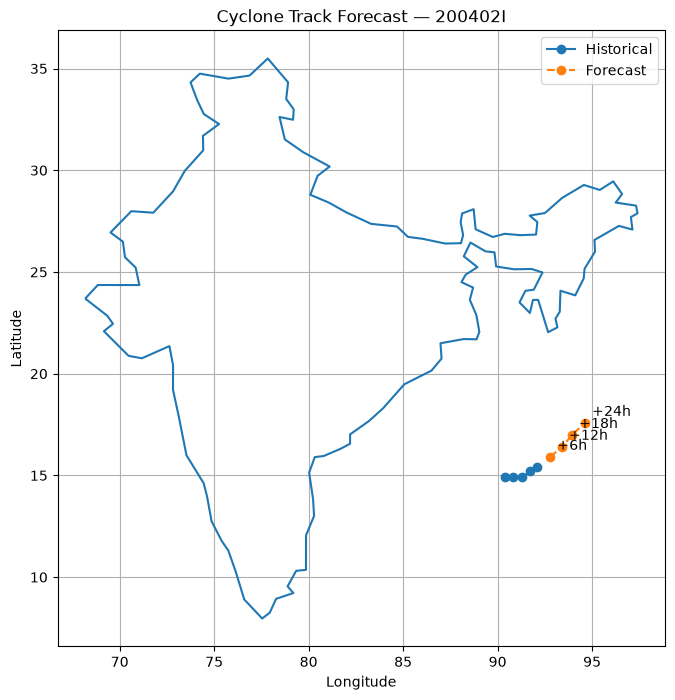

In [262]:
import matplotlib.pyplot as plt

# Pick one cyclone forecast
sample = final_forecast.iloc[0]

history_lat = np.array(sample["lat_history"], dtype=float)
history_lon = np.array(sample["lon_history"], dtype=float)

forecast_lat = [
    sample["lat_6h"],
    sample["lat_12h"],
    sample["lat_18h"],
    sample["lat_24h"]
]

forecast_lon = [
    sample["lon_6h"],
    sample["lon_12h"],
    sample["lon_18h"],
    sample["lon_24h"]
]

plt.figure(figsize=(10, 8))

# Historical track
plt.plot(
    history_lon,
    history_lat,
    marker="o",
    label="Historical"
)

# Forecast track
plt.plot(
    forecast_lon,
    forecast_lat,
    marker="o",
    linestyle="--",
    label="Forecast"
)

# Forecast labels
for lon, lat, h in zip(
    forecast_lon,
    forecast_lat,
    [6, 12, 18, 24]
):
    plt.annotate(
        f"+{h}h",
        (lon, lat),
        xytext=(5, 5),
        textcoords="offset points"
    )

# India boundary
india.boundary.plot(
    ax=plt.gca()
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    f"Cyclone Track Forecast — {sample['ID']}"
)

plt.legend()
plt.grid(True)
plt.show()

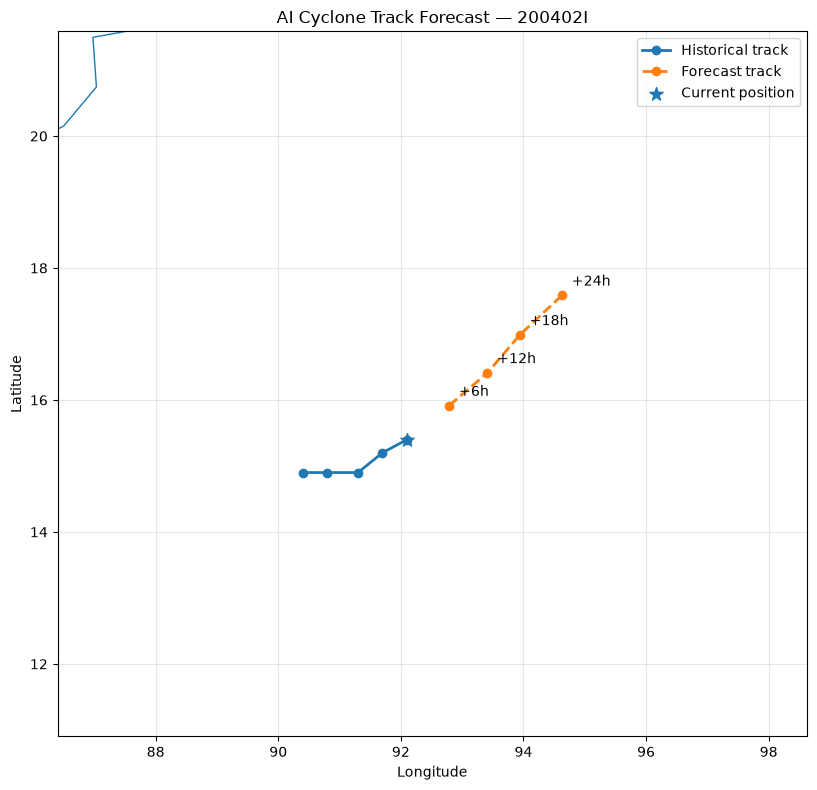

In [263]:
import matplotlib.pyplot as plt
import numpy as np

sample = final_forecast.iloc[0]

history_lat = np.array(sample["lat_history"], dtype=float)
history_lon = np.array(sample["lon_history"], dtype=float)

forecast_lat = np.array([
    sample["lat_6h"],
    sample["lat_12h"],
    sample["lat_18h"],
    sample["lat_24h"]
])

forecast_lon = np.array([
    sample["lon_6h"],
    sample["lon_12h"],
    sample["lon_18h"],
    sample["lon_24h"]
])

# Zoom region around cyclone
all_lat = np.concatenate([history_lat, forecast_lat])
all_lon = np.concatenate([history_lon, forecast_lon])

margin = 4

fig, ax = plt.subplots(figsize=(10, 8))

# India coastline
india.boundary.plot(
    ax=ax,
    linewidth=1
)

# Historical track
ax.plot(
    history_lon,
    history_lat,
    marker="o",
    linewidth=2,
    label="Historical track"
)

# Forecast track
ax.plot(
    forecast_lon,
    forecast_lat,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Forecast track"
)

# Current position
ax.scatter(
    history_lon[-1],
    history_lat[-1],
    s=100,
    marker="*",
    label="Current position"
)

# Forecast labels
for lon, lat, h in zip(
    forecast_lon,
    forecast_lat,
    [6, 12, 18, 24]
):
    ax.annotate(
        f"+{h}h",
        (lon, lat),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10
    )

ax.set_xlim(
    all_lon.min() - margin,
    all_lon.max() + margin
)

ax.set_ylim(
    all_lat.min() - margin,
    all_lat.max() + margin
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title(
    f"AI Cyclone Track Forecast — {sample['ID']}"
)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

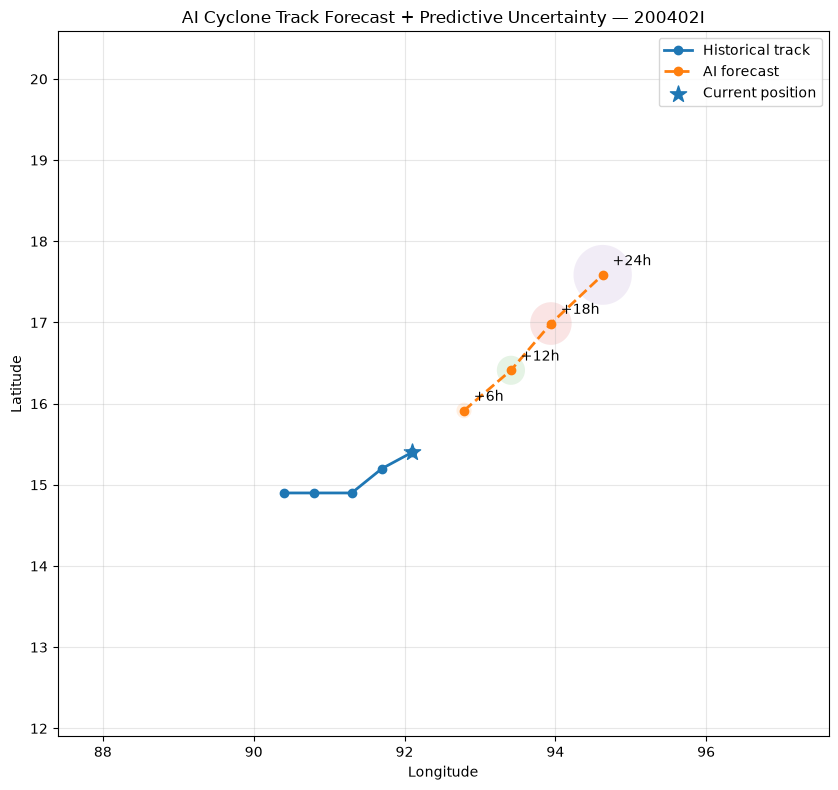

In [264]:
import matplotlib.pyplot as plt
import numpy as np

sample = final_forecast.iloc[0]

history_lat = np.array(sample["lat_history"], dtype=float)
history_lon = np.array(sample["lon_history"], dtype=float)

forecast_lat = np.array([
    sample["lat_6h"],
    sample["lat_12h"],
    sample["lat_18h"],
    sample["lat_24h"]
])

forecast_lon = np.array([
    sample["lon_6h"],
    sample["lon_12h"],
    sample["lon_18h"],
    sample["lon_24h"]
])

# MC-Dropout uncertainty in km
uncertainty_km = np.array([
    10.65,
    19.90,
    29.18,
    40.95
])

# Convert km to approximate degrees
lat_radius = uncertainty_km / 111.0

# Longitude degree conversion depends on latitude
lon_radius = uncertainty_km / (
    111.0 * np.cos(np.radians(forecast_lat))
)

fig, ax = plt.subplots(figsize=(10, 8))

# India coastline
india.boundary.plot(
    ax=ax,
    linewidth=1
)

# Historical track
ax.plot(
    history_lon,
    history_lat,
    marker="o",
    linewidth=2,
    label="Historical track"
)

# Forecast track
ax.plot(
    forecast_lon,
    forecast_lat,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="AI forecast"
)

# Current position
ax.scatter(
    history_lon[-1],
    history_lat[-1],
    marker="*",
    s=150,
    label="Current position"
)

# Uncertainty regions
for lon, lat, rx, ry in zip(
    forecast_lon,
    forecast_lat,
    lon_radius,
    lat_radius
):
    theta = np.linspace(0, 2*np.pi, 100)

    ellipse_lon = lon + rx * np.cos(theta)
    ellipse_lat = lat + ry * np.sin(theta)

    ax.fill(
        ellipse_lon,
        ellipse_lat,
        alpha=0.12
    )

# Forecast labels
for lon, lat, h in zip(
    forecast_lon,
    forecast_lat,
    [6, 12, 18, 24]
):
    ax.annotate(
        f"+{h}h",
        (lon, lat),
        xytext=(7, 7),
        textcoords="offset points"
    )

# Zoom
all_lat = np.concatenate([
    history_lat,
    forecast_lat
])

all_lon = np.concatenate([
    history_lon,
    forecast_lon
])

ax.set_xlim(
    all_lon.min() - 3,
    all_lon.max() + 3
)

ax.set_ylim(
    all_lat.min() - 3,
    all_lat.max() + 3
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title(
    f"AI Cyclone Track Forecast + Predictive Uncertainty — {sample['ID']}"
)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [265]:
from pathlib import Path

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    reports_dir / "cyclone_track_uncertainty_200402I.png",
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", reports_dir / "cyclone_track_uncertainty_200402I.png")

Saved: ../reports/cyclone_track_uncertainty_200402I.png


<Figure size 640x480 with 0 Axes>

In [266]:
import pandas as pd
import numpy as np

results_summary = pd.DataFrame([
    {
        "Task": "Intensity (+6h)",
        "Model": "Multimodal CNN + GRU",
        "Metric": "MAE",
        "Value": 3.47,
        "Unit": "kt"
    },
    {
        "Task": "Track (+6h)",
        "Model": "Velocity-only GRU",
        "Metric": "Mean Error",
        "Value": 26.04,
        "Unit": "km"
    },
    {
        "Task": "Track (+12h)",
        "Model": "Multi-step GRU",
        "Metric": "Mean Error",
        "Value": 57.26,
        "Unit": "km"
    },
    {
        "Task": "Track (+18h)",
        "Model": "Multi-step GRU",
        "Metric": "Mean Error",
        "Value": 91.22,
        "Unit": "km"
    },
    {
        "Task": "Track (+24h)",
        "Model": "Multi-step GRU",
        "Metric": "Mean Error",
        "Value": 128.58,
        "Unit": "km"
    },
    {
        "Task": "RI Classification",
        "Model": "Metadata-only GRU",
        "Metric": "ROC-AUC",
        "Value": 0.6113,
        "Unit": ""
    },
    {
        "Task": "RI Classification",
        "Model": "Metadata-only GRU",
        "Metric": "PR-AUC",
        "Value": 0.2383,
        "Unit": ""
    },
    {
        "Task": "RI Classification",
        "Model": "Metadata-only GRU",
        "Metric": "F1",
        "Value": 0.3011,
        "Unit": ""
    }
])

display(results_summary)

,Task,Model,Metric,Value,Unit
0,Intensity (+6h),Multimodal CNN + GRU,MAE,3.4700,kt
1,Track (+6h),Velocity-only GRU,Mean Error,26.0400,km
2,Track (+12h),Multi-step GRU,Mean Error,57.2600,km
3,Track (+18h),Multi-step GRU,Mean Error,91.2200,km
4,Track (+24h),Multi-step GRU,Mean Error,128.5800,km
5,RI Classification,Metadata-only GRU,ROC-AUC,0.6113,
6,RI Classification,Metadata-only GRU,PR-AUC,0.2383,
7,RI Classification,Metadata-only GRU,F1,0.3011,


In [267]:
uncertainty_summary = pd.DataFrame({
    "Horizon": ["+6h", "+12h", "+18h", "+24h"],
    "Mean Predictive Spread (km)": [
        10.65,
        19.90,
        29.18,
        40.95
    ]
})

display(uncertainty_summary)

,Horizon,Mean Predictive Spread (km)
0,+6h,10.65
1,+12h,19.90
2,+18h,29.18
3,+24h,40.95


In [268]:
reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

results_summary.to_csv(
    reports_dir / "final_results_summary.csv",
    index=False
)

uncertainty_summary.to_csv(
    reports_dir / "uncertainty_summary.csv",
    index=False
)

print("Final evaluation files saved.")

Final evaluation files saved.


In [269]:
final_results = {
    "intensity": {
        "model": "Multimodal CNN + GRU",
        "mae_kt": 3.47,
        "baseline_metadata_only_mae_kt": 3.31
    },

    "track": {
        "6h": {
            "velocity_only_km": 26.04,
            "motion_trend_km": 27.76
        },
        "12h": {
            "multistep_gru_km": 57.26,
            "motion_trend_km": 62.91
        },
        "18h": {
            "multistep_gru_km": 91.22,
            "motion_trend_km": 103.61
        },
        "24h": {
            "multistep_gru_km": 128.58,
            "motion_trend_km": 149.56
        }
    },

    "ri": {
        "model": "Metadata-only GRU",
        "roc_auc": 0.6113,
        "pr_auc": 0.2383,
        "f1": 0.3011
    },

    "uncertainty_km": {
        "6h": 10.65,
        "12h": 19.90,
        "18h": 29.18,
        "24h": 40.95
    }
}

import json

with open(
    reports_dir / "final_results.json",
    "w"
) as f:
    json.dump(final_results, f, indent=2)

print("Saved final_results.json")

Saved final_results.json


In [270]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 40.2 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.6/797.6 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 28.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 22.4 MB/s eta 0:00:00 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
